# GLOBAL HIERARCHY TESTS

The same plot will be made in cases where ~
    
   **NEQS=05/Lambda2:**
    
    Narrow: [1.4e-4,4.2e-4]
    Moderate: [-2.5e-3,2.5e-3]
    Kinney/Caliguri: [-5e-2,5e-2]
    Expanded:[-0.5,0.5]


   **NEQS=06/Lambda3:**
    
    Narrow: [-6.9e-6,-2.3e-6]
    Moderate:[-2.5e-5,2.5e-4]
    Kinney/Caliguri:[-5e-3,5e-3]
    Expanded:[-0.05,0.05]

   **NEQS=07/Lambda4:**
    
    Narrow:[3.4e-8,1.03e-7]
    Moderate:[-2.5e-6,2.5e-5]
    Kinney/Caliguri:[-5e-4,5e-4]
    Expanded:[-5e-3, 5e-3]

   **NEQS=08/Lambda5:**
    
    Narrow:[-4.46e-9,-1.34e-8]
    Moderate:[-2.5e-8,2.5e-6]
    Kinney/Caliguri:[-5e-5,5e-5]
    Expanded:[-5e-4, 5e-4]


Make specific imports:

In [10]:
import numpy
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt

import sys
import os
import glob


#Should modify the Python import path at runtime
sys.path.append('/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels')

import numpy as np
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm


from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import re

from scipy.interpolate import UnivariateSpline, splrep, splev, CubicSpline, interp1d, PchipInterpolator, InterpolatedUnivariateSpline
import numdifftools as nd
from scipy.integrate import cumulative_trapezoid, solve_ivp, odeint


from pathlib import Path



In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors as mcolors
from matplotlib.gridspec import GridSpec

SCAN_INFO = {
    5: ("lam2",  r"\lambda_2"),
    6: ("lam3",  r"\lambda_3"),
    7: ("lam4",  r"\lambda_4"),
    8: ("lam5",  r"\lambda_5"),
    9: ("lam6",  r"\lambda_6"),
    10: ("lam7", r"\lambda_7"),
    11: ("lam8", r"\lambda_8"),
    12: ("lam9", r"\lambda_9"),
    13: ("lam10", r"\lambda_{10}"),
}


def plot_big_normalized_scan_summary(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    index=0,
    k_ref=0.05,
    N_ref=60.0,
    ref_floor_spec=1e-30,
    ref_floor_bg=1e-20,
    frac_floor=1e-100,
    H_scale=1.0,
    V_scale=1.0,
    cmap_name="plasma",
    save_name=None,
    suptitle=None,
    show=True,
):
    """
    Build one large figure containing:

      Row 1: normalized P_s(k), normalized P_t(k)
      Row 2: fractional error in normalized P_s(k), fractional error in normalized P_t(k)
      Row 3: normalized H(N), fractional error in normalized H(N)
      Row 4: normalized V(phi), fractional error in normalized V(phi)
      Row 5: summary stats table for Pt and H

    Definitions
    -----------
    Spectra are shape-normalized:
        P_s_norm(k) = P_s(k) / P_s(k_ref)
        P_t_norm(k) = P_t(k) / P_t(k_ref)

    Background curves are normalized at N_ref:
        H_norm(N)   = H(N) / H(N_ref)
        V_norm(phi) = V(phi) / V(N_ref)

    Error curves are fractional differences relative to the chosen base model:
        (curve - curve_base) / curve_base
    """

    def get_scan_info(neqs):
        if neqs not in SCAN_INFO:
            raise ValueError(f"Unsupported NEQS = {neqs}")
        return SCAN_INFO[neqs]

    def sanitize_lam_values(vals):
        return np.array(
            [x[0] if isinstance(x, tuple) else x for x in vals],
            dtype=float
        )

    def prepare_increasing(x, y):
        """
        Accept monotonic x only.
        If fully decreasing, reverse x and y together.
        Refuse non-monotonic arrays.
        """
        x = np.asarray(x)
        y = np.asarray(y)

        if x.shape != y.shape:
            raise ValueError("x and y must have the same shape")

        dx = np.diff(x)

        if np.all(dx >= 0):
            return x, y
        elif np.all(dx <= 0):
            return x[::-1], y[::-1]
        else:
            raise ValueError(
                "x is not monotonic; refusing to reorder because that could distort physics."
            )

    def normalize_curve_at_ref(x, y, x_ref, ref_floor):
        x_use, y_use = prepare_increasing(x, y)

        if x_ref < np.min(x_use) or x_ref > np.max(x_use):
            raise ValueError(
                f"Reference x_ref={x_ref} outside range [{np.min(x_use)}, {np.max(x_use)}]"
            )

        y_ref = np.interp(x_ref, x_use, y_use)

        if np.abs(y_ref) < ref_floor:
            raise ValueError(
                f"Reference value too small for normalization at x_ref={x_ref}: {y_ref:.3e}"
            )

        return x_use, y_use / y_ref, y_ref

    def fractional_difference_on_common_x(x_base, y_base, x_cmp, y_cmp, floor=1e-100):
        """
        Evaluate:
            (y_cmp_interp - y_base) / y_base
        on the overlap, using the base grid.
        """
        x_base, y_base = prepare_increasing(x_base, y_base)
        x_cmp, y_cmp = prepare_increasing(x_cmp, y_cmp)

        xmin = max(np.min(x_base), np.min(x_cmp))
        xmax = min(np.max(x_base), np.max(x_cmp))

        mask = (x_base >= xmin) & (x_base <= xmax)
        x_use = x_base[mask]
        y_base_use = y_base[mask]
        y_cmp_interp = np.interp(x_use, x_cmp, y_cmp)

        denom = np.where(np.abs(y_base_use) > floor, y_base_use, np.nan)
        frac = (y_cmp_interp - y_base_use) / denom
        return x_use, frac

    def load_specs(value):
        val_str = f"{value:.10e}"
        folder = os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

        file_s = os.path.join(folder, f"spec_s_neqs{NEQS}.dat")
        file_t = os.path.join(folder, f"spec_t_neqs{NEQS}.dat")

        data_s = np.loadtxt(file_s)
        data_t = np.loadtxt(file_t)

        k_s = data_s[:, 0]
        Ps = np.abs(data_s[:, 1])

        k_t = data_t[:, 0]
        Pt = np.abs(data_t[:, 1])

        return k_s, Ps, k_t, Pt

    def load_path(value):
        val_str = f"{value:.10e}"
        folder = os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

        file_path = os.path.join(
            folder,
            f"path_neqs{NEQS}_{scan_name}_{val_str}.dat"
        )

        return pd.read_csv(file_path, sep=r"\s+", header=None).values



    def extract_cols(path_data):
        """
        Assumed column convention:
            phi = 0
            H   = 1
            N   = NEQS
            V   = NEQS + 1
        """
        phi = path_data[:, 0]
        H = path_data[:, 1]
        N = path_data[:, NEQS]
        V = path_data[:, NEQS + 1]
        return phi, H, N, V

    def get_normalized_H_vs_N(path_data):
        _, H, N, _ = extract_cols(path_data)
        N_use, H_norm, H_ref = normalize_curve_at_ref(N, H, N_ref, ref_floor_bg)
        return N_use, H_norm, H_ref

#     def get_normalized_V_vs_phi(path_data):
#         phi_raw, _, N_raw, V_raw = extract_cols(path_data)

#         # First use monotonic N ordering for physical trajectory order
#         N_use, phi_use = prepare_increasing(N_raw, phi_raw)
#         _, V_use = prepare_increasing(N_raw, V_raw)

#         if N_ref < np.min(N_use) or N_ref > np.max(N_use):
#             raise ValueError(
#                 f"N_ref={N_ref} outside range [{np.min(N_use)}, {np.max(N_use)}]"
#             )

#         V_ref = np.interp(N_ref, N_use, V_use)

#         if np.abs(V_ref) < ref_floor_bg:
#             raise ValueError(
#                 f"Reference V(N_ref) too small at N_ref={N_ref}: {V_ref:.3e}"
#             )

#         V_norm = V_use / V_ref

    def get_normalized_V_vs_phi(path_data):
        phi_raw, _, N_raw, V_raw = extract_cols(path_data)

        N_use, phi_use = prepare_increasing(N_raw, phi_raw)
        _, V_use = prepare_increasing(N_raw, V_raw)


        if N_ref < np.min(N_use) or N_ref > np.max(N_use):
            raise ValueError(
                f"N_ref={N_ref} outside range [{np.min(N_use)}, {np.max(N_use)}]"
            )

        V_ref = np.interp(N_ref, N_use, V_use)

        if np.abs(V_ref) < ref_floor_bg:
            raise ValueError(
                f"Reference V(N_ref) too small at N_ref={N_ref}: {V_ref:.3e}"
            )
        V_norm = V_use / V_ref

#         phi_plot, V_plot = prepare_increasing(phi_use, V_norm)
#         return phi_plot, V_plot, V_ref



        # Then prepare phi-space version
#         phi_plot, V_plot = prepare_increasing(phi_use, V_norm)
        
        phi_plot = phi_use
        V_plot = V_norm
        return phi_plot, V_plot, V_ref
   

    def setup_colorbar(fig, axes, lam_vals, scan_symbol, cmap_name="plasma"):
#         cmap = cm.get_cmap(cmap_name)
        import matplotlib as mpl
        cmap = mpl.colormaps[cmap_name]
        norm = mcolors.Normalize(vmin=np.min(lam_vals), vmax=np.max(lam_vals))
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)

        cbar = fig.colorbar(
            sm,
            ax=axes,
            orientation="vertical",
            fraction=0.015,
            pad=0.02
        )
        cbar.set_label(rf"${scan_symbol}$", fontsize=12)
        return cmap, norm

    # ---------------- setup ----------------
    scan_name, scan_symbol = get_scan_info(NEQS)
    lamX_numeric = sanitize_lam_values(lamX_values)

    # ---------------- base model ----------------
    try:
        k_s_base, Ps_base, k_t_base, Pt_base = load_specs(baseX)
        path_base = load_path(baseX)
    except FileNotFoundError as e:
        raise FileNotFoundError(
            f"Base model files not found for {scan_name} = {baseX:.5e}"
        ) from e

    k_s_base, Ps_base_norm, _ = normalize_curve_at_ref(
        k_s_base, Ps_base, k_ref, ref_floor_spec
    )
    k_t_base, Pt_base_norm, _ = normalize_curve_at_ref(
        k_t_base, Pt_base, k_ref, ref_floor_spec
    )

    N_H_base, H_base_norm, _ = get_normalized_H_vs_N(path_base)
    phi_V_base, V_base_norm, _ = get_normalized_V_vs_phi(path_base)

    # ---------------- figure ----------------
    fig = plt.figure(figsize=(18, 22), constrained_layout=True)
    gs = GridSpec(
        5, 2,
        figure=fig,
        height_ratios=[1.0, 1.0, 1.0, 1.0, 1.1]
    )

    ax_ps       = fig.add_subplot(gs[0, 0])
    ax_pt       = fig.add_subplot(gs[0, 1])
    ax_ps_err   = fig.add_subplot(gs[1, 0])
    ax_pt_err   = fig.add_subplot(gs[1, 1])
    ax_h        = fig.add_subplot(gs[2, 0])
    ax_h_err    = fig.add_subplot(gs[2, 1])
    ax_vphi     = fig.add_subplot(gs[3, 0])
    ax_vphi_err = fig.add_subplot(gs[3, 1])
    ax_table    = fig.add_subplot(gs[4, :])
    ax_table.axis("off")

    plot_axes = [ax_ps, ax_pt, ax_ps_err, ax_pt_err, ax_h, ax_h_err, ax_vphi, ax_vphi_err]
    cmap, norm = setup_colorbar(fig, plot_axes, lamX_numeric, scan_symbol, cmap_name=cmap_name)

    # ---------------- scan loop ----------------
    stats_rows = []

    for lamX in lamX_numeric:
        try:
            k_s, Ps, k_t, Pt = load_specs(lamX)
            path_data = load_path(lamX)

            # normalize spectra
            k_s_use, Ps_norm, _ = normalize_curve_at_ref(
                k_s, Ps, k_ref, ref_floor_spec
            )
            k_t_use, Pt_norm, _ = normalize_curve_at_ref(
                k_t, Pt, k_ref, ref_floor_spec
            )

            # normalize background
            N_H, H_norm, _ = get_normalized_H_vs_N(path_data)
            phi_V, V_norm, _ = get_normalized_V_vs_phi(path_data)

            color = cmap(norm(lamX))

            # fractional differences relative to base
            k_ps_err, frac_ps = fractional_difference_on_common_x(
                k_s_base, Ps_base_norm, k_s_use, Ps_norm, floor=frac_floor
            )
            k_pt_err, frac_pt = fractional_difference_on_common_x(
                k_t_base, Pt_base_norm, k_t_use, Pt_norm, floor=frac_floor
            )
            N_h_err, frac_h = fractional_difference_on_common_x(
                N_H_base, H_base_norm, N_H, H_norm, floor=frac_floor
            )
            phi_v_err, frac_v = fractional_difference_on_common_x(
                phi_V_base, V_base_norm, phi_V, V_norm, floor=frac_floor
            )

            # top/background plots
#             ax_ps.plot(k_s_use, Ps_norm, color=color, lw=1.6, alpha=0.9)
            k_max_scalar = 10.0
            mask_k = k_s_use <= k_max_scalar

            ax_ps.plot(
                k_s_use[mask_k],
                Ps_norm[mask_k],
                color=color,
                lw=1.6,
                alpha=0.9
            )
            ax_pt.plot(k_t_use, Pt_norm, color=color, lw=1.6, alpha=0.9)
            ax_h.plot(N_H, H_scale * H_norm, color=color, lw=1.6, alpha=0.9)
            ax_vphi.plot(phi_V, V_scale * V_norm, color=color, lw=1.6, alpha=0.9)

            # error plots
#             ax_ps_err.plot(k_ps_err, frac_ps, color=color, lw=1.6, alpha=0.9)
            mask_k_err = k_ps_err <= k_max_scalar

            ax_ps_err.plot(
                k_ps_err[mask_k_err],
                frac_ps[mask_k_err],
                color=color,
                lw=1.6,
                alpha=0.9
            )
            ax_pt_err.plot(k_pt_err, frac_pt, color=color, lw=1.6, alpha=0.9)
            ax_h_err.plot(N_h_err, frac_h, color=color, lw=1.6, alpha=0.9)
            ax_vphi_err.plot(phi_v_err, frac_v, color=color, lw=1.6, alpha=0.9)

            # summary table values
            mask_ps_stats = k_ps_err <= k_max_scalar
            frac_ps_use = frac_ps[mask_ps_stats]

            stats_rows.append({
                "lamX": lamX,

                # tensor (%)
                "mean_dPt_pct": 100 * np.nanmean(frac_pt),
                "max_dPt_pct": 100 * np.nanmax(np.abs(frac_pt)),

                # scalar (%), restricted k
                "mean_dPs_pct": 100 * np.nanmean(frac_ps_use),
                "max_dPs_pct": 100 * np.nanmax(np.abs(frac_ps_use)),

                # background (%)
                "mean_dH_pct": 100 * np.nanmean(frac_h),
                "max_dH_pct": 100 * np.nanmax(np.abs(frac_h)),

                "mean_dV_pct": 100 * np.nanmean(frac_v),
                "max_dV_pct": 100 * np.nanmax(np.abs(frac_v)),
            })

        except FileNotFoundError:
            print(f"Missing files for {scan_name} = {lamX:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name} = {lamX:.5e}: {e}")

    stats_df = pd.DataFrame(stats_rows)

    # ---------------- titles ----------------
    ax_ps.set_title(
        rf"Normalized scalar spectrum: $\mathcal{{P}}_\mathcal{{R}}(k)/\mathcal{{P}}_\mathcal{{R}}({k_ref})$"
    )
    ax_pt.set_title(
        rf"Normalized tensor spectrum: $\mathcal{{P}}_t(k)/\mathcal{{P}}_t({k_ref})$"
    )

    ax_ps_err.set_title(r"Fractional error in normalized $\mathcal{P}_{\mathcal{R}}(k)$")
    ax_pt_err.set_title(r"Fractional error in normalized $\mathcal{P}_t(k)$")

    ax_h.set_title(rf"Normalized Hubble parameter: $H(N)/H({N_ref})$")
    ax_h_err.set_title(r"Fractional error in normalized $H(N)$")

    ax_vphi.set_title(rf"Normalized potential: $V(\phi)/V(N={N_ref})$")
    ax_vphi_err.set_title(r"Fractional error in normalized $V(\phi)$")

    # ---------------- y labels ----------------
    ax_ps.set_ylabel(r"$\mathcal{P}_{\mathcal{R},\mathrm{norm}}$")
    ax_pt.set_ylabel(r"$\mathcal{P}_{t,\mathrm{norm}}$")

    ax_ps_err.set_ylabel(
        r"$\left(\mathcal{P}_{\mathcal{R},\mathrm{norm}}-\mathcal{P}_{\mathcal{R},\mathrm{base}}\right)/\mathcal{P}_{\mathcal{R},\mathrm{base}}$"
    )
    ax_pt_err.set_ylabel(
        r"$\left(\mathcal{P}_{t,\mathrm{norm}}-\mathcal{P}_{t,\mathrm{base}}\right)/\mathcal{P}_{t,\mathrm{base}}$"
    )

    if H_scale == 1.0:
      
        ax_h.set_ylabel(r"$H/H(N_{\mathrm{ref}})$")
    else:
#         ax_h.set_ylabel(rf"${H_scale:.0e}\,H/H(N_{{\mathrm{{ref}}}})$")
        ax_h.set_ylabel(rf"$10^{6}H/H(N_{{\mathrm{{ref}}}})$")


    ax_h_err.set_ylabel(
        r"$\left(H_{\mathrm{norm}}-H_{\mathrm{base}}\right)/H_{\mathrm{base}}$"
    )

    if V_scale == 1.0:
        ax_vphi.set_ylabel(r"$V/V(N_{\mathrm{ref}})$")
    else:
#         ax_vphi.set_ylabel(rf"${V_scale:.0e}\,V/V(N_{{\mathrm{{ref}}}})$")
        ax_vphi.set_ylabel(rf"$10^{{13}}V/V(N_{{\mathrm{{ref}}}})$")


    ax_vphi_err.set_ylabel(
        r"$\left(V_{\mathrm{norm}}-V_{\mathrm{base}}\right)/V_{\mathrm{base}}$"
    )

    # ---------------- x labels ----------------
    ax_ps_err.set_xlabel(r"$k \,[h\,\mathrm{Mpc}^{-1}]$")
    ax_pt_err.set_xlabel(r"$k \,[h\,\mathrm{Mpc}^{-1}]$")
    ax_h.set_xlabel(r"$N$")
    ax_h_err.set_xlabel(r"$N$")
    ax_vphi.set_xlabel(r"$\phi$")
    ax_vphi_err.set_xlabel(r"$\phi$")

    # ---------------- styling ----------------
    # spectra: log x and log y
    for ax in [ax_ps, ax_pt]:
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(True, alpha=0.25)
        ax.minorticks_on()

    # spectra errors: log x only
    for ax in [ax_ps_err, ax_pt_err]:
        ax.set_xscale("log")
        ax.axhline(0.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
        ax.grid(True, alpha=0.25)
        ax.minorticks_on()

    # H plot: inverted x and log y
    ax_h.invert_xaxis()
#     ax_h.set_yscale("log")
    ax_h.grid(True, alpha=0.25)

    # H error: inverted x, linear y
    ax_h_err.invert_xaxis()
    ax_h_err.axhline(0.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax_h_err.grid(True, alpha=0.25)

    # V(phi) plot: inverted x and log y
#     ax_vphi.invert_xaxis()
#     ax_vphi.set_yscale("log")
    ax_vphi.grid(True, alpha=0.25)

    # V(phi) error: inverted x, linear y
#     ax_vphi_err.invert_xaxis()
    ax_vphi_err.axhline(0.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax_vphi_err.grid(True, alpha=0.25)
# ---------------- simple printed summary ----------------
    ax_table.set_visible(False)

    ax_table.set_visible(False)

    if not stats_df.empty:
        print("\n=== Summary Statistics (% difference from base) ===\n")

        display_df = stats_df.copy()

        for col in display_df.columns:
            if col == "lamX":
                display_df[col] = display_df[col].map(lambda x: f"{x:.2e}")
            else:
                display_df[col] = display_df[col].map(lambda x: f"{x:.3f}%")

        print(display_df.to_string(index=False))
    else:
        print("\nNo valid models loaded.\n")

    # ---------------- title / save ----------------
    if suptitle is None:
        suptitle = (
            rf"Normalized spectra and background summary for NEQS={NEQS} "
            rf"(${scan_symbol}$ scan, base = {baseX:.2e})"
        )
    fig.suptitle(suptitle, fontsize=17)

    if save_name is None:
        save_name = f"neqs{NEQS}_{scan_name}_big_normalized_summary.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)
        
    phi, H, N, V = extract_cols(path_base)

    print("phi at max N:", phi[np.argmax(N)])
    print("phi at min N:", phi[np.argmin(N)])

    return stats_df

In [23]:
# def get_param_values_from_dirs(NEQS, param_name, base_path_root, show_summary=True):
#     """
#     Scan directories for parameter values and optionally show summary statistics
    
#     Parameters:
#     -----------
#     NEQS : int
#         Number of equations (e.g., 6, 7, 8)
#     param_name : str
#         Parameter name (e.g., "lam3", "lam4")
#     base_path_root : str
#         Root path to search -- specific to where shit is saved
#     show_summary : bool
#         If True, print summary information about models found
    
#     Returns:
#     --------
#     list of tuples **this is important the face that it is tuples**
#         [(value, label), ...] for each parameter value found
#     """
    
#     #We will have to define the base_path_root first where the neqs files live
#     base_path = f"{base_path_root}/neqs{NEQS}"
#     #Once the path is defined, we will create search pattern for directories with param_name should be lamX
#     pattern = os.path.join(base_path, f"{param_name}_*")
#     #Glob will find all dirs that match serarch pattern
#     dirs = glob.glob(pattern)

#     #Initialize a values list:
#     values = []
#     #Then for every directory corresponding to search pattern we will do...
#     for d in dirs:
#         try:
#             # lam3_-4.6e-06 → "-4.6e-06"
#             #extract basename of directory and split it with underscores to get the second part
#             val_str = os.path.basename(d).split("_")[1] #basename bit
#             val = float(val_str) #string
#             label = rf"${param_name} = {val:.1e}$"
#             values.append((val, label)) #creates tuple of value and label and adds it to list 
#         except Exception as e: #if we dont get the directory name with expected format, it will skip
#             print(f"Skipping {d}: {e}")
    
#     # Then we can sort by parameter value (first value in each tuple)
#     #I believe this sorting should be fine we are just organizing the values of lamX that have already ran
#     values.sort(key=lambda x: x[0])
    
#     #We can print a summary if we want
#     if show_summary:
#         print(f"\n{'='*60}")
#         print(f"Summary for NEQS={NEQS}, parameter={param_name}")
#         print(f"{'='*60}")
#         print(f"Total models found: {len(values)}")
#         print(f"Parameter range: {values[0][0]:.3e} to {values[-1][0]:.3e}")
#         print(f"{'='*60}\n")
    
#     return values


def get_param_values_from_dirs(NEQS, param_name, base_path_root, show_summary=True):
    base_path = f"{base_path_root}/neqs{NEQS}"
    pattern = os.path.join(base_path, f"{param_name}_*")
    dirs = glob.glob(pattern)

    values = []

    for d in dirs:
        try:
            base = os.path.basename(d)
            val_str = base.replace(f"{param_name}_", "")
            val = float(val_str)
            label = rf"${param_name} = {val:.1e}$"
            values.append((val, label))
        except Exception as e:
            print(f"Skipping {d}: {e}")

    values.sort(key=lambda x: x[0])

    if show_summary:
        print(f"\n{'='*60}")
        print(f"Summary for NEQS={NEQS}, parameter={param_name}")
        print(f"{'='*60}")
        print(f"Total models found: {len(values)}")
        if len(values) > 0:
            print(f"Parameter range: {values[0][0]:.3e} to {values[-1][0]:.3e}")
        else:
            print("Parameter range: none found")
        print(f"{'='*60}\n")

    return values

In [ ]:
## If I wanna check N ranges:

In [27]:
def check_saved_path_N_ranges(NEQS, base_path_root):
    base_path = os.path.join(base_path_root, f"neqs{NEQS}")
    folders = sorted(glob.glob(os.path.join(base_path, "lam3_*")))

    rows = []

    for folder in folders:
        lam3_str = os.path.basename(folder).replace("lam3_", "")
        path_pattern = os.path.join(folder, f"path_neqs{NEQS}_lam3_{lam3_str}.dat")
        matches = glob.glob(path_pattern)

        if len(matches) == 0:
            print(f"Missing path in {folder}")
            continue

        path_file = matches[0]
        data = pd.read_csv(path_file, sep=r"\s+", header=None).values

        N = data[:, NEQS]
        eps = data[:, 2]

        rows.append({
            "lam3": float(lam3_str),
            "path_file": path_file,
            "N_min": np.min(N),
            "N_max": np.max(N),
            "N_span": np.max(N) - np.min(N),
            "N_first": N[0],
            "N_last": N[-1],
            "eps_first": eps[0],
            "eps_last": eps[-1],
            "covers_N60": np.min(N) <= 60.0 <= np.max(N),
            "covers_N0": np.min(N) <= 0.0 <= np.max(N),
        })

    df = pd.DataFrame(rows).sort_values("lam3")

    print("\n=== Saved path N-range check ===")
    print(df[[
        "lam3", "N_min", "N_max", "N_span",
        "N_first", "N_last", "eps_first", "eps_last",
        "covers_N60", "covers_N0"
    ]].to_string(index=False))

    print("\n=== Potential problems ===")
    bad = df[(df["N_max"] < 59.9) | (df["N_min"] > 0.1)]
    if len(bad) == 0:
        print("All paths look like they cover roughly N=60 down to N=0.")
    else:
        print(bad[["lam3", "N_min", "N_max", "N_span", "path_file"]].to_string(index=False))

    return df

In [ ]:
### If i wanna see spread of Ps and Pt for tighter ns range

In [47]:
def plot_filtered_spectra_by_ns(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    ns_min=0.955,
    ns_max=0.970,
    ns_target=0.967,
    k_ref=0.05,
    k_max_scalar=10.0,
    cmap_name="plasma",
    save_name=None,
    show=True,
):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib import cm, colors as mcolors

    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):
        return np.array([x[0] if isinstance(x, tuple) else x for x in vals], dtype=float)

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

    def load_observables(value):
        arr = np.loadtxt(os.path.join(folder_for(value), f"test_nr_neqs{NEQS}.dat"))
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]

    def load_specs(value):
        folder = folder_for(value)
        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))
        return s[:, 0], np.abs(s[:, 1]), t[:, 0], np.abs(t[:, 1])

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        dx = np.diff(x)

        if np.all(dx >= 0):
            return x, y
        elif np.all(dx <= 0):
            return x[::-1], y[::-1]
        else:
            raise ValueError("x grid is not monotonic")

    def normalize_at_ref(x, y, x_ref):
        x, y = prepare_increasing(x, y)
        y_ref = np.interp(x_ref, x, y)
        return x, y / y_ref

    def frac_on_base_grid(x_base, y_base, x_cmp, y_cmp, kmax=None):
        x_base, y_base = prepare_increasing(x_base, y_base)
        x_cmp, y_cmp = prepare_increasing(x_cmp, y_cmp)

        xmin = max(np.min(x_base), np.min(x_cmp))
        xmax = min(np.max(x_base), np.max(x_cmp))

        # ONLY upper cutoff
        if kmax is not None:
            xmax = min(xmax, kmax)

        mask = (x_base >= xmin) & (x_base <= xmax)
        x_use = x_base[mask]
        y_base_use = y_base[mask]
        y_cmp_interp = np.interp(x_use, x_cmp, y_cmp)

        frac = (y_cmp_interp - y_base_use) / y_base_use
        return x_use, frac

    lam_vals = sanitize_lam_values(lamX_values)

    r_base, ns_base, alpha_base = load_observables(baseX)

    k_s_base_raw, Ps_base_raw, k_t_base_raw, Pt_base_raw = load_specs(baseX)

    k_s_base, Ps_base_norm = normalize_at_ref(k_s_base_raw, Ps_base_raw, k_ref)
    k_t_base, Pt_base_norm = normalize_at_ref(k_t_base_raw, Pt_base_raw, k_ref)

    rows = []
    kept_models = []

    for lamX in lam_vals:
        try:
            r, ns, alpha_s = load_observables(lamX)

            k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(lamX)

            k_s, Ps_norm = normalize_at_ref(k_s_raw, Ps_raw, k_ref)
            k_t, Pt_norm = normalize_at_ref(k_t_raw, Pt_raw, k_ref)

            k_ps_err, frac_ps = frac_on_base_grid(
                k_s_base, Ps_base_norm, k_s, Ps_norm, kmax=k_max_scalar
            )

            k_pt_err, frac_pt = frac_on_base_grid(
                k_t_base, Pt_base_norm, k_t, Pt_norm, kmax=None
            )

            mean_dPs_pct = 100.0 * np.nanmean(frac_ps)
            max_dPs_pct = 100.0 * np.nanmax(np.abs(frac_ps))
            mean_dPt_pct = 100.0 * np.nanmean(frac_pt)
            max_dPt_pct = 100.0 * np.nanmax(np.abs(frac_pt))

            keep = ns_min <= ns <= ns_max

            row = {
                "lamX": lamX,
                "r": r,
                "ns": ns,
                "alpha_s": alpha_s,
                "delta_ns_from_base": ns - ns_base,
                "delta_ns_from_target": ns - ns_target,
                "mean_dPs_pct": mean_dPs_pct,
                "max_dPs_pct": max_dPs_pct,
                "mean_dPt_pct": mean_dPt_pct,
                "max_dPt_pct": max_dPt_pct,
                "kept_by_ns_cut": keep,
            }

            rows.append(row)

            if keep:
                kept_models.append({
                    **row,
                    "k_s": k_s,
                    "Ps_norm": Ps_norm,
                    "k_t": k_t,
                    "Pt_norm": Pt_norm,
                    "k_ps_err": k_ps_err,
                    "frac_ps": frac_ps,
                    "k_pt_err": k_pt_err,
                    "frac_pt": frac_pt,
                })

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={lamX:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name}={lamX:.5e}: {e}")

    stats_df = pd.DataFrame(rows).sort_values("ns")
    kept_df = stats_df[stats_df["kept_by_ns_cut"]].copy()

    print("\n=== All models summary ===")
    print(f"Total loaded: {len(stats_df)}")
    print(f"Base ns: {ns_base:.6f}")
    print(f"Models in ns window [{ns_min}, {ns_max}]: {len(kept_df)}")

    if not kept_df.empty:
        print("\n=== Filtered models by ns cut ===")
        print(
            kept_df[[
                "lamX", "ns", "delta_ns_from_base",
                "mean_dPs_pct", "max_dPs_pct",
                "mean_dPt_pct", "max_dPt_pct"
            ]].to_string(index=False)
        )

        print("\n=== Error shrink check (in percentages) ===")
        print("All models:")
        print(
            stats_df[["mean_dPs_pct", "max_dPs_pct", "mean_dPt_pct", "max_dPt_pct"]]
            .agg(["mean", "max"])
            .to_string()
        )
        print("\nFiltered models:")
        print(
            kept_df[["mean_dPs_pct", "max_dPs_pct", "mean_dPt_pct", "max_dPt_pct"]]
            .agg(["mean", "max"])
            .to_string()
        )

    fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

    ax_ps, ax_pt = axes[0]
    ax_ps_err, ax_pt_err = axes[1]

    if len(kept_models) > 0:
        lam_kept = np.array([m["lamX"] for m in kept_models])
        cmap = plt.get_cmap(cmap_name)
        norm = mcolors.Normalize(vmin=np.min(lam_kept), vmax=np.max(lam_kept))

        for m in kept_models:
            color = cmap(norm(m["lamX"]))

            mask_ps_plot = m["k_s"] <= k_max_scalar

            ax_ps.loglog(
                m["k_s"][mask_ps_plot],
                m["Ps_norm"][mask_ps_plot],
                color=color,
                lw=1.8,
                alpha=0.85,
            )

            ax_pt.loglog(
                m["k_t"],
                m["Pt_norm"],
                color=color,
                lw=1.8,
                alpha=0.85,
            )

            ax_ps_err.semilogx(
                m["k_ps_err"],
                100.0 * m["frac_ps"],
                color=color,
                lw=1.5,
                alpha=0.85,
            )

            ax_pt_err.semilogx(
                m["k_pt_err"],
                100.0 * m["frac_pt"],
                color=color,
                lw=1.5,
                alpha=0.85,
            )

        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        fig.colorbar(sm, ax=axes, label=rf"${scan_symbol}$")

    mask_base_s = k_s_base <= k_max_scalar

    ax_ps.loglog(
        k_s_base[mask_base_s],
        Ps_base_norm[mask_base_s],
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_pt.loglog(
        k_t_base,
        Pt_base_norm,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    for ax in [ax_ps_err, ax_pt_err]:
        ax.axhline(0.0, color="black", ls="--", lw=0.8, alpha=0.6)

    ax_ps.axvline(k_ref, color="black", ls=":", alpha=0.7)
    ax_pt.axvline(k_ref, color="black", ls=":", alpha=0.7)

    ax_ps.set_title(rf"Filtered normalized scalar spectra: $P_s/P_s({k_ref})$")
    ax_pt.set_title(rf"Filtered normalized tensor spectra: $P_t/P_t({k_ref})$")
    ax_ps_err.set_title(r"Filtered scalar fractional error")
    ax_pt_err.set_title(r"Filtered tensor fractional error")

    ax_ps.set_xlabel(r"$k$")
    ax_pt.set_xlabel(r"$k$")
    ax_ps_err.set_xlabel(r"$k$")
    ax_pt_err.set_xlabel(r"$k$")

    ax_ps.set_ylabel(r"$P_s/P_s(k_{\rm ref})$")
    ax_pt.set_ylabel(r"$P_t/P_t(k_{\rm ref})$")
    ax_ps_err.set_ylabel(r"% difference in $P_s$")
    ax_pt_err.set_ylabel(r"% difference in $P_t$")

    # ONLY upper cutoff behavior:
    ax_ps.set_xlim(np.min(k_s_base), k_max_scalar)
    ax_ps_err.set_xlim(np.min(k_ps_err), k_max_scalar)

    for ax in axes.ravel():
        ax.grid(True, alpha=0.25)
        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(fontsize=8)

    fig.suptitle(
        rf"Models with ${ns_min} \leq n_s \leq {ns_max}$ "
        rf"(target $n_s={ns_target}$)",
        fontsize=16,
    )

    if save_name is None:
        save_name = f"neqs{NEQS}_{scan_name}_filtered_ns_{ns_min}_{ns_max}.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return stats_df, kept_df

In [ ]:
##spread plot

In [48]:
def plot_Ps_Pt_error_envelopes(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    ns_min=0.955,
    ns_max=0.970,
    k_ref=0.05,
    k_max_scalar=10.0,
    ref_floor=1e-30,
    frac_floor=1e-100,
    exclude_base=True,
    save_name=None,
):
    import os
    import numpy as np
    import matplotlib.pyplot as plt

    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize(vals):
        return np.array([x[0] if isinstance(x, tuple) else x for x in vals], dtype=float)

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

    def load_ns(value):
        arr = np.loadtxt(os.path.join(folder_for(value), f"test_nr_neqs{NEQS}.dat"))
        arr = np.atleast_1d(arr)
        return arr[1]

    def load_specs(value):
        folder = folder_for(value)
        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))
        return s[:, 0], np.abs(s[:, 1]), t[:, 0], np.abs(t[:, 1])

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        if np.any(np.diff(x) < 0):
            return x[::-1], y[::-1]
        return x, y

    def normalize(x, y):
        x, y = prepare_increasing(x, y)

        if k_ref < np.min(x) or k_ref > np.max(x):
            raise ValueError(f"k_ref={k_ref} outside k range [{np.min(x)}, {np.max(x)}]")

        y_ref = np.interp(k_ref, x, y)

        if np.abs(y_ref) < ref_floor:
            raise ValueError(f"Reference value too small at k_ref={k_ref}: {y_ref:.3e}")

        return x, y / y_ref

    def frac_on_base(x_base, y_base, x_cmp, y_cmp, kmax=None):
        x_base, y_base = prepare_increasing(x_base, y_base)
        x_cmp, y_cmp = prepare_increasing(x_cmp, y_cmp)

        xmin = max(np.min(x_base), np.min(x_cmp))
        xmax = min(np.max(x_base), np.max(x_cmp))

        # ONLY upper cutoff
        if kmax is not None:
            xmax = min(xmax, kmax)

        mask = (x_base >= xmin) & (x_base <= xmax)

        x = x_base[mask]
        yb = y_base[mask]
        yc = np.interp(x, x_cmp, y_cmp)

        frac = (yc - yb) / np.where(np.abs(yb) > frac_floor, yb, np.nan)
        return x, frac

    lam_vals = sanitize(lamX_values)

    ns_base = load_ns(baseX)

    k_s_b, Ps_b, k_t_b, Pt_b = load_specs(baseX)
    k_s_b, Ps_b = normalize(k_s_b, Ps_b)
    k_t_b, Pt_b = normalize(k_t_b, Pt_b)

    ps_curves = []
    pt_curves = []

    for lam in lam_vals:
        try:
            ns = load_ns(lam)

            if not (ns_min <= ns <= ns_max):
                continue

            if exclude_base and np.isclose(lam, baseX, rtol=0.0, atol=1e-18):
                continue

            k_s, Ps, k_t, Pt = load_specs(lam)

            k_s, Ps = normalize(k_s, Ps)
            k_t, Pt = normalize(k_t, Pt)

            k_ps, frac_ps = frac_on_base(
                k_s_b, Ps_b, k_s, Ps, kmax=k_max_scalar
            )

            k_pt, frac_pt = frac_on_base(
                k_t_b, Pt_b, k_t, Pt, kmax=None
            )

            ps_curves.append((k_ps, frac_ps))
            pt_curves.append((k_pt, frac_pt))

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={lam:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name}={lam:.5e}: {e}")

    if len(ps_curves) == 0 or len(pt_curves) == 0:
        print("No valid curves found.")
        return

    def build_envelope(curves):
        k_grid = curves[0][0]
        stack = []

        for k, f in curves:
            if len(k) != len(k_grid) or not np.allclose(k, k_grid):
                f = np.interp(k_grid, k, f)
            stack.append(f)

        stack = np.asarray(stack)

        mean_abs_pct = 100.0 * np.nanmean(np.abs(stack), axis=0)
        max_abs_pct = 100.0 * np.nanmax(np.abs(stack), axis=0)

        return k_grid, mean_abs_pct, max_abs_pct

    k_ps, mean_ps, max_ps = build_envelope(ps_curves)
    k_pt, mean_pt, max_pt = build_envelope(pt_curves)

    print("\n=== Error envelope summary, in percentages ===")
    print(f"Models used: {len(ps_curves)}")
    print(f"ns window: [{ns_min}, {ns_max}]")
    print(f"Base ns: {ns_base:.6f}")
    print(f"Scalar k range plotted: {np.min(k_ps):.3e} to {np.max(k_ps):.3e}")
    print(f"Tensor k range plotted: {np.min(k_pt):.3e} to {np.max(k_pt):.3e}")
    print(f"Mean max Ps error: {np.nanmean(mean_ps):.4f}%")
    print(f"Max Ps envelope: {np.nanmax(max_ps):.4f}%")
    print(f"Mean max Pt error: {np.nanmean(mean_pt):.4f}%")
    print(f"Max Pt envelope: {np.nanmax(max_pt):.4f}%")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    ax1.plot(k_ps, mean_ps, lw=2.5, label="mean")
    ax1.fill_between(k_ps, 0.0, max_ps, alpha=0.3, label="max envelope")

    ax2.plot(k_pt, mean_pt, lw=2.5, label="mean")
    ax2.fill_between(k_pt, 0.0, max_pt, alpha=0.3, label="max envelope")

    ax1.set_title(r"Scalar spectrum $P_s$")
    ax2.set_title(r"Tensor spectrum $P_t$")

    ax1.set_xlabel(r"$k$")
    ax2.set_xlabel(r"$k$")

    ax1.set_ylabel(r"% difference from base")
    ax2.set_ylabel(r"% difference from base")

    # ONLY upper cutoff behavior for scalar:
    ax1.set_xlim(np.min(k_ps), k_max_scalar)

    for ax in (ax1, ax2):
        ax.set_xscale("log")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=10)

    fig.suptitle(
        rf"NEQS={NEQS}, ${scan_symbol}$ scan, "
        rf"${ns_min} \leq n_s \leq {ns_max}$",
        fontsize=15
    )

    if save_name is None:
        save_name = f"neqs{NEQS}_{scan_name}_Ps_Pt_error_envelopes.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

## NEQs = 5 and $\lambda_2$:


Summary for NEQS=5, parameter=lam2
Total models found: 97
Parameter range: -4.500e-01 to 4.900e-01

Missing files for lam2 = -4.50000e-01
Missing files for lam2 = -4.40000e-01
Missing files for lam2 = -3.50000e-01
Missing files for lam2 = -3.30000e-01
Missing files for lam2 = -3.10000e-01
Missing files for lam2 = -2.70000e-01
Missing files for lam2 = -2.40000e-01
Missing files for lam2 = -2.10000e-01
Missing files for lam2 = -2.00000e-01
Missing files for lam2 = -4.60000e-02
Missing files for lam2 = -4.40000e-02
Missing files for lam2 = -4.30000e-02
Missing files for lam2 = -4.20000e-02
Missing files for lam2 = -4.00000e-02
Missing files for lam2 = -3.70000e-02
Missing files for lam2 = -3.40000e-02
Missing files for lam2 = -3.30000e-02
Missing files for lam2 = -2.40000e-02
Missing files for lam2 = -2.00000e-02
Missing files for lam2 = -1.80000e-02
Missing files for lam2 = -1.50000e-02
Missing files for lam2 = -8.10000e-03
Missing files for lam2 = -8.00000e-03
Missing files for lam2 = 

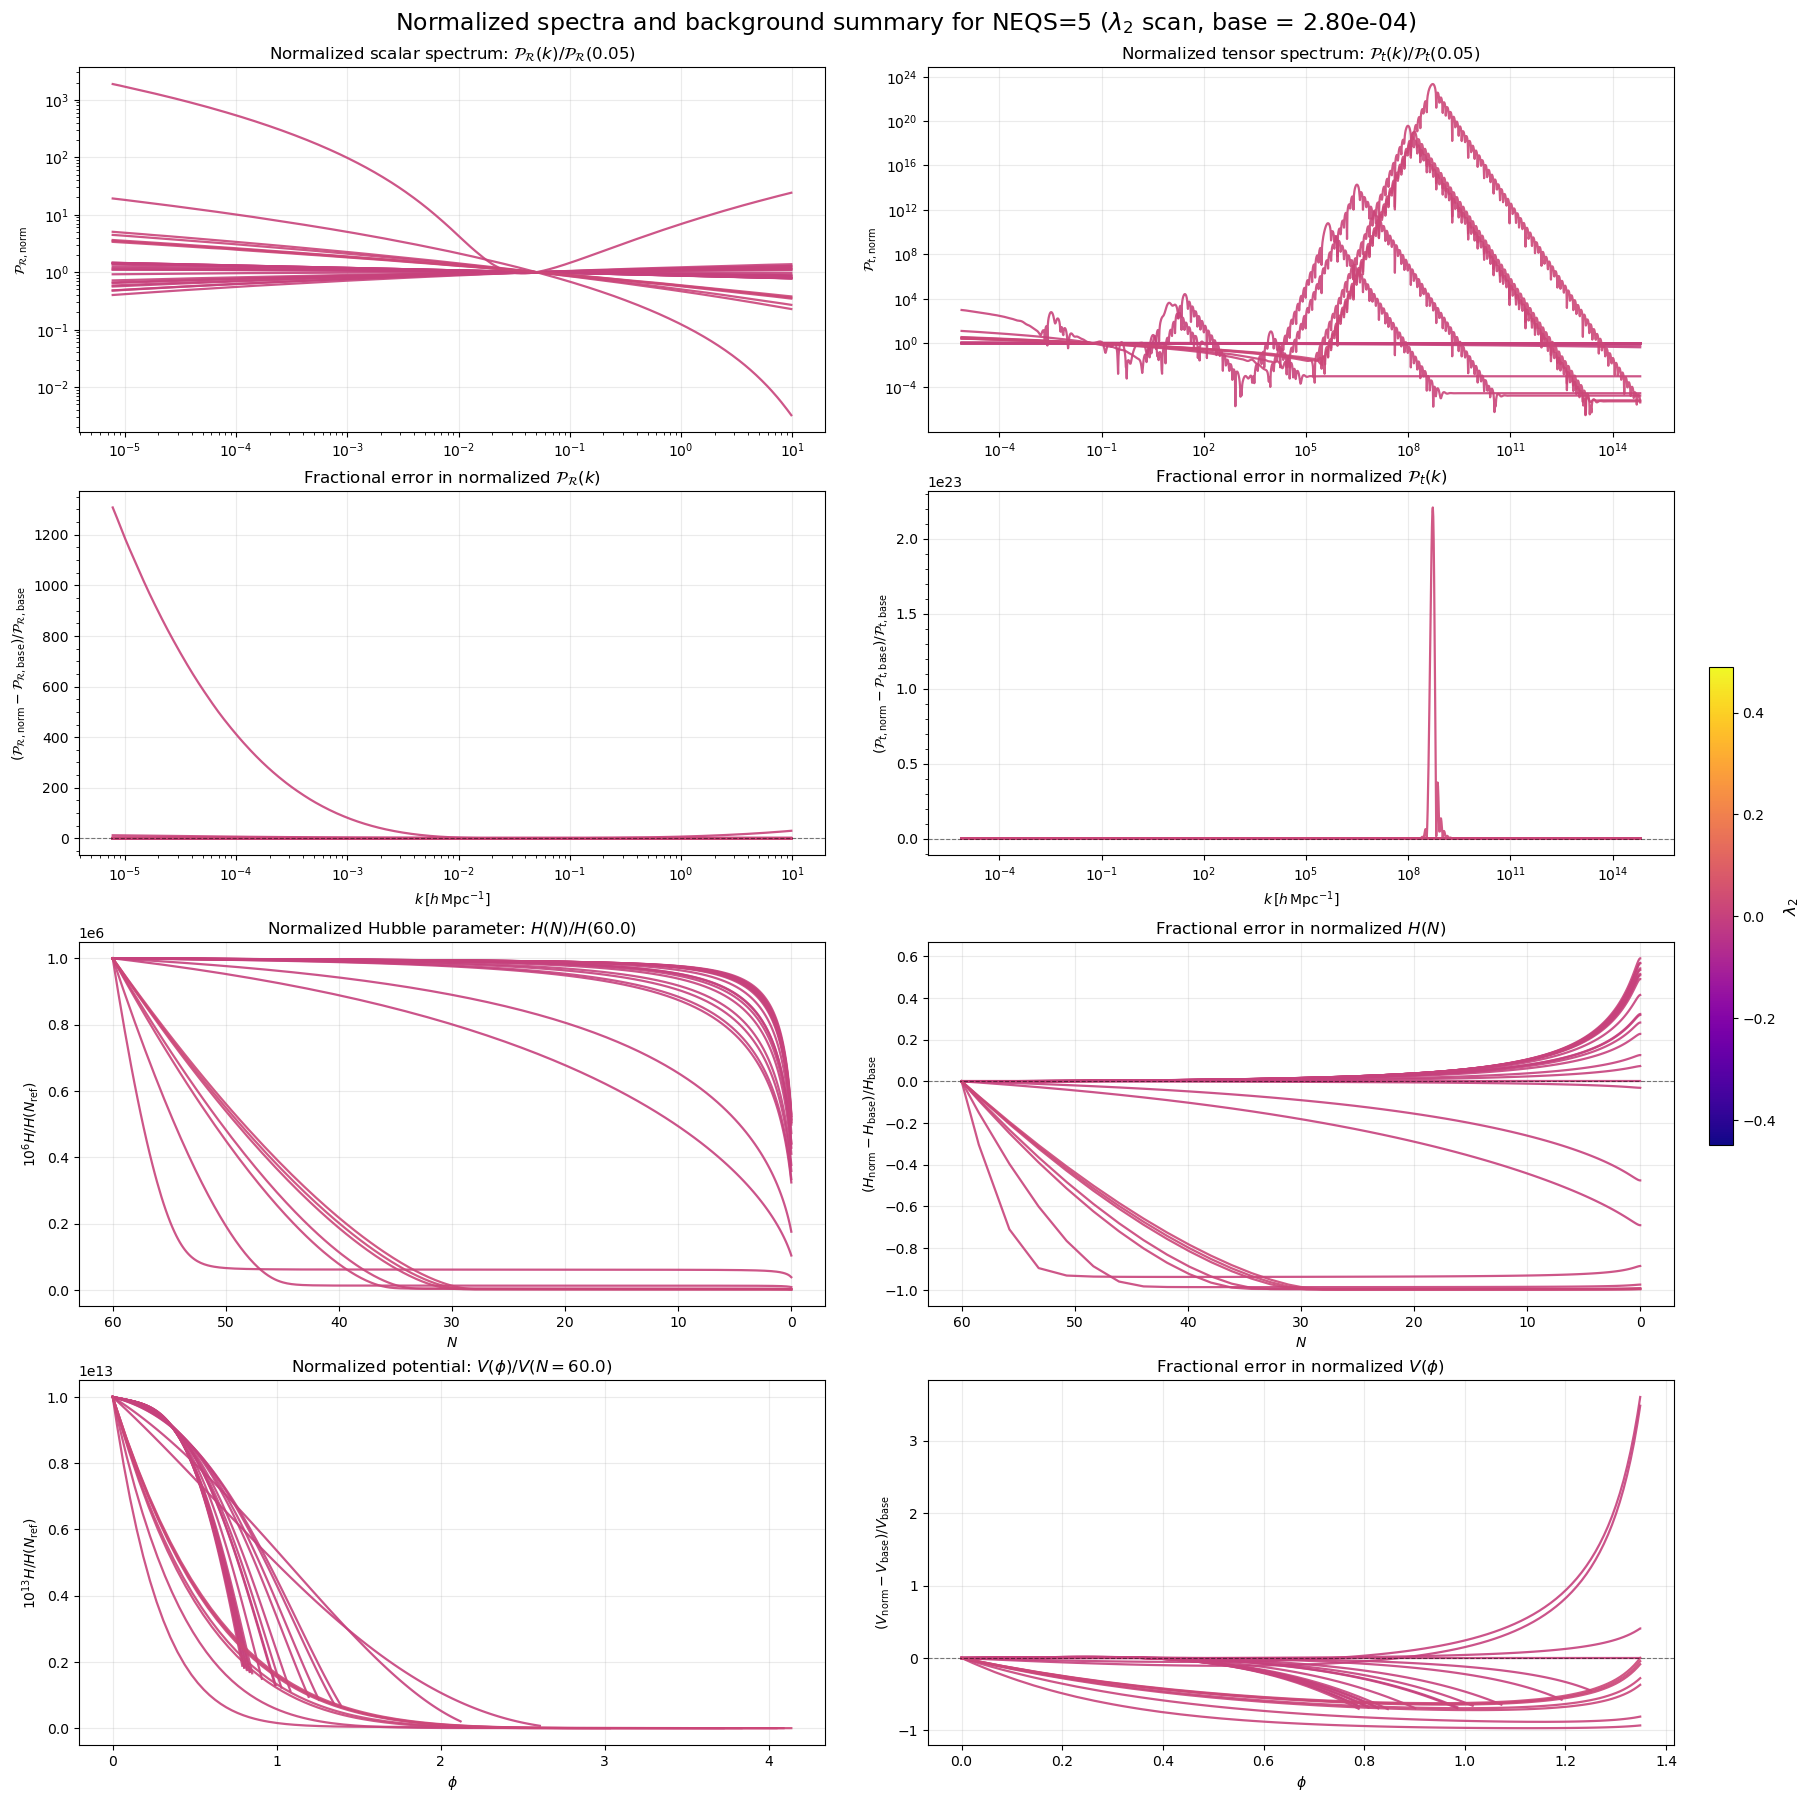

phi at max N: 0.0
phi at min N: 1.348593
        lamX  mean_dPt_pct   max_dPt_pct  mean_dPs_pct    max_dPs_pct  \
0  -0.000024 -1.786491e+01  5.306223e+01      0.242423       1.231935   
1   0.000000 -9.530550e+00  3.131717e+01      0.283606       1.288740   
2   0.000240 -3.057395e-01  1.214591e+00      0.056480       0.750222   
3   0.000280  0.000000e+00  0.000000e+00      0.000000       0.000000   
4   0.000380  6.030383e-01  2.473034e+00     -0.650574       2.939312   
5   0.000470  9.536485e-01  3.967393e+00     -1.226340       5.752537   
6   0.000690  1.460668e+00  6.225736e+00     -2.760405      13.131053   
7   0.000840  1.659485e+00  7.155175e+00     -3.856320      18.561937   
8   0.000950  1.768546e+00  7.681156e+00     -4.677993      22.675063   
9   0.000970  1.781622e+00  7.745236e+00     -4.772519      23.253997   
10  0.001300  1.980657e+00  8.765741e+00     -7.230545      36.206397   
11  0.001700  2.078697e+00  9.353105e+00     -9.612884      50.068933   
12  0.0018

In [39]:

base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"
lam2_values = get_param_values_from_dirs(5, "lam2", base_path_root)


stats_df = plot_big_normalized_scan_summary(
    NEQS=5,
    lamX_values=lam2_values,
    baseX=2.8e-04,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    index=0,
    k_ref=0.05,
    N_ref=60.0,
    H_scale=1e6,     
    V_scale=1e13,    
    save_name="expanded_neqs5_lam2_big_summary.png"
)

print(stats_df)

## NEQs = 6 and $\lambda_3$:


Summary for NEQS=6, parameter=lam3
Total models found: 20
Parameter range: -8.759e-05 to 0.000e+00


=== Summary Statistics (% difference from base) ===

     lamX mean_dPt_pct max_dPt_pct mean_dPs_pct max_dPs_pct mean_dH_pct max_dH_pct mean_dV_pct max_dV_pct
-8.76e-05       1.046%      4.628%       4.360%     19.980%     19.258%    46.850%     -9.051%    61.668%
-8.26e-05       1.034%      4.582%       3.818%     17.291%     18.923%    45.881%     -8.450%    57.846%
-8.18e-05       1.032%      4.575%       3.758%     16.883%     18.872%    45.735%     -8.363%    57.292%
-7.98e-05       1.028%      4.555%       3.488%     15.800%     18.729%    45.324%     -9.281%    62.510%
-7.30e-05       1.010%      4.483%       2.763%     12.433%     18.214%    43.855%     -9.522%    63.414%
-6.92e-05       0.999%      4.438%       2.490%     10.718%     17.903%    42.976%     -8.962%    59.916%
-6.71e-05       0.993%      4.411%       2.207%      9.661%     17.720%    42.462%     -8.650%    57.95

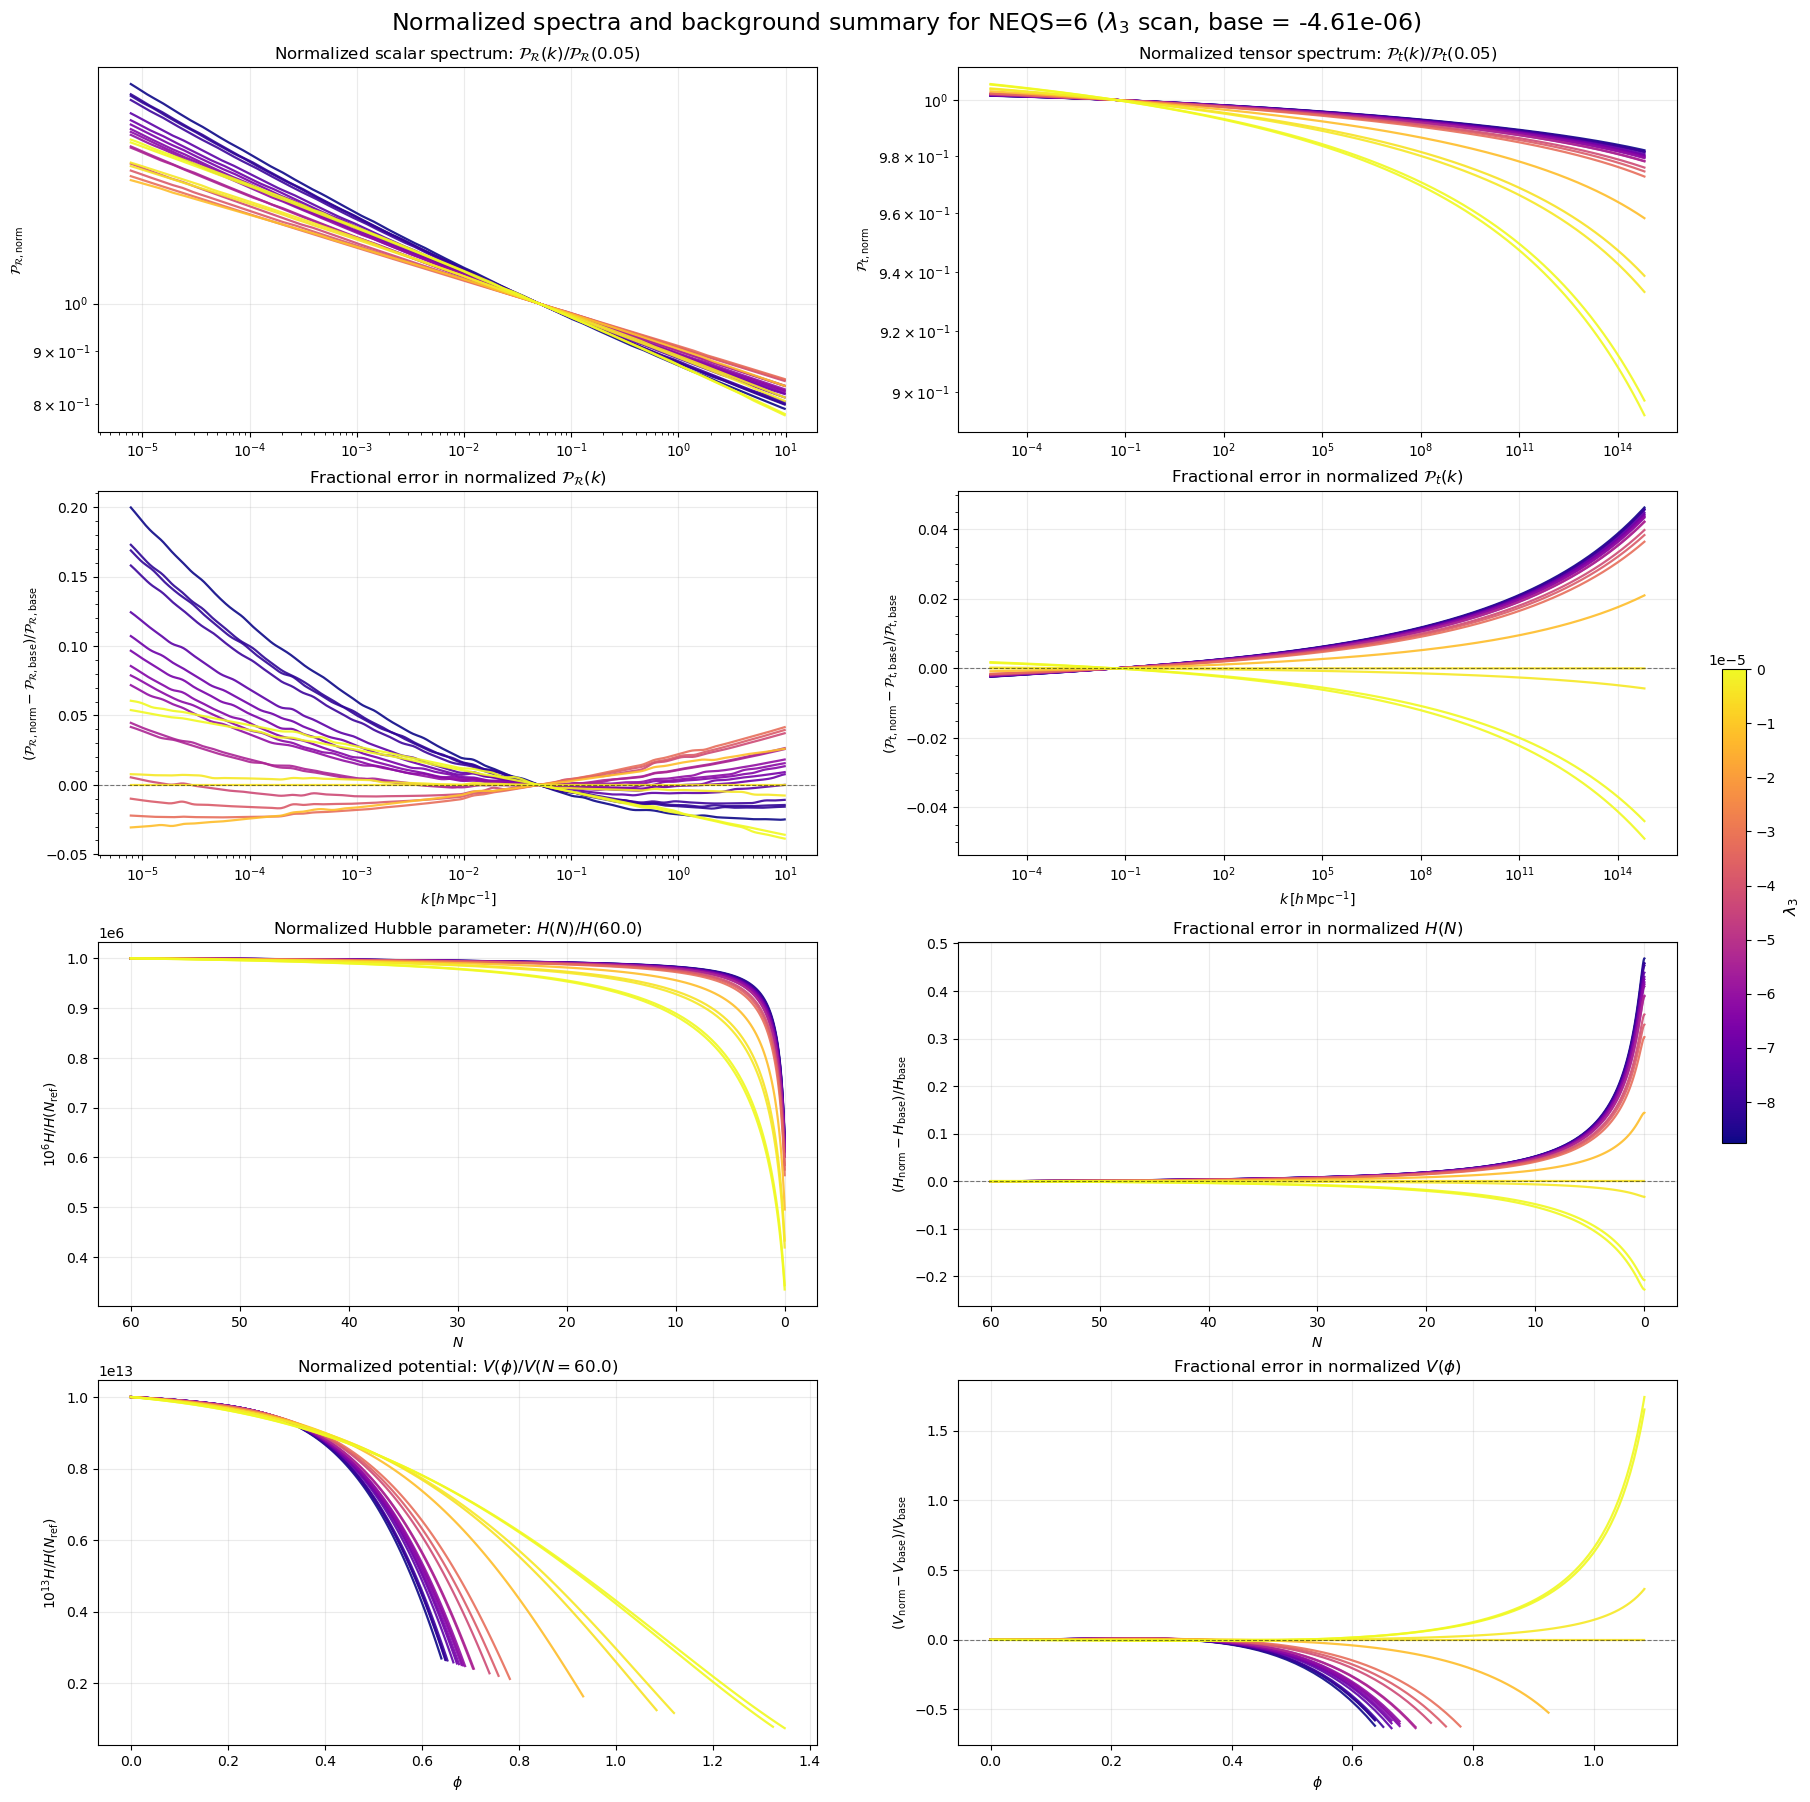

phi at max N: 0.0
phi at min N: 1.084339
            lamX  mean_dPt_pct  max_dPt_pct  mean_dPs_pct  max_dPs_pct  \
0  -8.759358e-05      1.045577     4.627612      4.359632    19.979921   
1  -8.255015e-05      1.034159     4.581982      3.817689    17.291477   
2  -8.181654e-05      1.032426     4.575003      3.758263    16.883392   
3  -7.978910e-05      1.027530     4.555221      3.488104    15.800143   
4  -7.296435e-05      1.009813     4.482700      2.762755    12.432524   
5  -6.917605e-05      0.999008     4.437886      2.490081    10.718153   
6  -6.705256e-05      0.992596     4.411102      2.207146     9.661417   
7  -6.454758e-05      0.984679     4.377798      1.971588     8.561551   
8  -6.288467e-05      0.979183     4.354590      1.842269     7.885803   
9  -6.122648e-05      0.973495     4.330491      1.780185     7.183781   
10 -5.452411e-05      0.948099     4.221880      1.138617     4.468202   
11 -5.385109e-05      0.945302     4.209841      1.088833     4.172522 

In [49]:

base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"
lam3_values = get_param_values_from_dirs(6, "lam3", base_path_root)


stats_df = plot_big_normalized_scan_summary(
    NEQS=6,
    lamX_values=lam3_values,
    baseX=-4.6097100000e-6,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    index=0,
    k_ref=0.05,
    N_ref=60.0,
    H_scale=1e6,    
    V_scale=1e13,    
    save_name="expanded_neqs6_lam3_big_summary.png"
)

print(stats_df)

In [50]:
base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"

Ncheck_df = check_saved_path_N_ranges(
    NEQS=6,
    base_path_root=base_path_root
)


=== Saved path N-range check ===
         lam3    N_min  N_max    N_span  N_first  N_last  eps_first  eps_last  covers_N60  covers_N0
-8.759358e-05 0.000001   60.0 59.999999 0.000001    60.0   0.999992  0.000081        True      False
-8.255015e-05 0.000002   60.0 59.999998 0.000002    60.0   0.999992  0.000085        True      False
-8.181654e-05 0.000001   60.0 59.999999 0.000001    60.0   0.999995  0.000086        True      False
-7.978910e-05 0.000001   60.0 59.999999 0.000001    60.0   0.999994  0.000087        True      False
-7.296435e-05 0.000002   60.0 59.999998 0.000002    60.0   0.999993  0.000092        True      False
-6.917605e-05 0.000001   60.0 59.999999 0.000001    60.0   0.999995  0.000095        True      False
-6.705256e-05 0.000001   60.0 59.999999 0.000001    60.0   0.999993  0.000097        True      False
-6.454758e-05 0.000026   60.0 59.999974 0.000026    60.0   0.999880  0.000099        True      False
-6.288467e-05 0.000001   60.0 59.999999 0.000001    60.0 


=== All models summary ===
Total loaded: 20
Base ns: 0.965678
Models in ns window [0.963, 0.968]: 5

=== Filtered models by ns cut ===
     lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-0.000043 0.964421           -0.001257      0.340033     3.721994      0.891939     3.977717
-0.000004 0.964739           -0.000939      0.067964     0.770892     -0.129312     0.577973
-0.000005 0.965678            0.000000      0.000000     0.000000      0.000000     0.000000
-0.000038 0.966154            0.000476     -0.047111     3.955280      0.859083     3.833244
-0.000032 0.967713            0.002035     -0.324473     4.159798      0.815881     3.642208

=== Error shrink check (in percentages) ===
All models:
      mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
mean      1.622298     8.108002      0.640219     3.829334
max       4.359632    19.979921      1.045577     4.897367

Filtered models:
      mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt

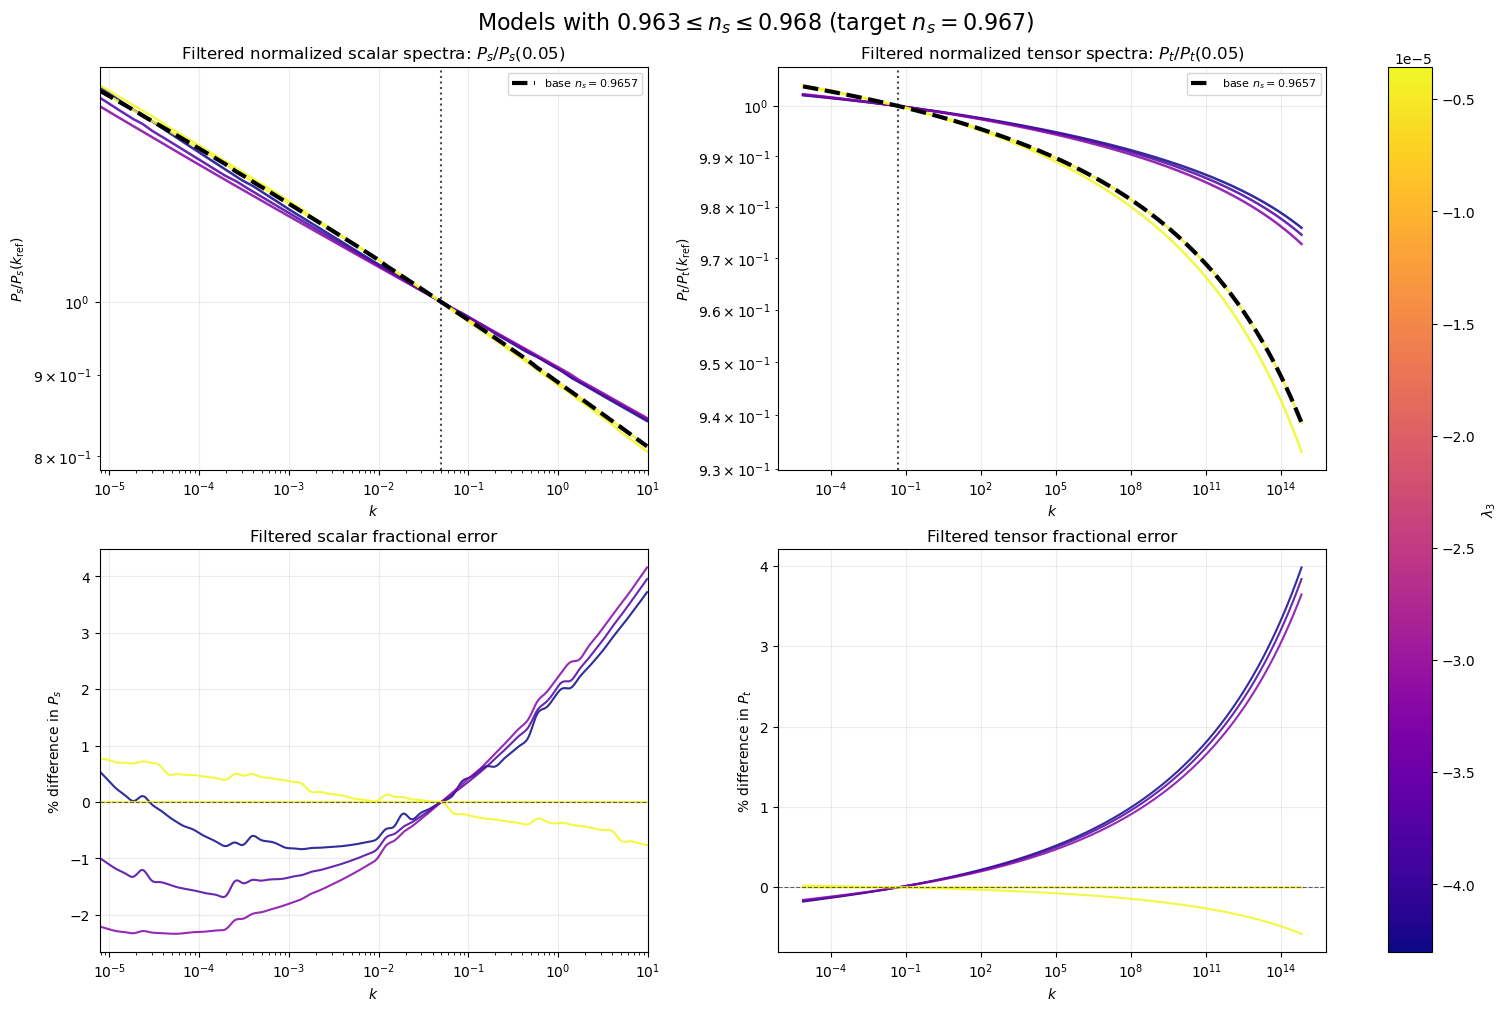

In [51]:
stats_df, kept_df = plot_filtered_spectra_by_ns(
    NEQS=6,
    lamX_values=lam3_values,
    baseX=-4.6097100000e-6,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    ns_min=0.963,
    ns_max=0.968,
    ns_target=0.967,
    k_ref=0.05,
    k_max_scalar=10.0,
    save_name="neqs6_lam3_filtered_ns_spectra.png"
)

In [59]:
def plot_filtered_Ps_Pt_error_envelopes_with_tilts(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    ns_min=0.955,
    ns_max=0.970,
    k_ref=0.05,
    k_fit_min=0.05,
    k_fit_max=10.0,
    k_max_scalar=10.0,
    ref_floor=1e-30,
    frac_floor=1e-100,
    exclude_base=True,
    save_name=None,
    show=True,
):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize(vals):
        return np.array([x[0] if isinstance(x, tuple) else x for x in vals], dtype=float)

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

    def load_observables(value):
        arr = np.loadtxt(os.path.join(folder_for(value), f"test_nr_neqs{NEQS}.dat"))
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]  # r, ns, alpha_s

    def load_specs(value):
        folder = folder_for(value)
        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))
        return s[:, 0], np.abs(s[:, 1]), t[:, 0], np.abs(t[:, 1])

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        dx = np.diff(x)

        if np.all(dx >= 0):
            return x, y
        elif np.all(dx <= 0):
            return x[::-1], y[::-1]
        else:
            raise ValueError("x grid is not monotonic")

    def normalize_at_ref(x, y, x_ref):
        x, y = prepare_increasing(x, y)

        if x_ref < np.min(x) or x_ref > np.max(x):
            raise ValueError(f"k_ref={x_ref} outside k range [{np.min(x)}, {np.max(x)}]")

        y_ref = np.interp(x_ref, x, y)

        if np.abs(y_ref) < ref_floor:
            raise ValueError(f"Reference value too small at k_ref={x_ref}: {y_ref:.3e}")

        return x, y / y_ref

    def frac_on_base_grid(x_base, y_base, x_cmp, y_cmp, kmax=None):
        x_base, y_base = prepare_increasing(x_base, y_base)
        x_cmp, y_cmp = prepare_increasing(x_cmp, y_cmp)

        xmin = max(np.min(x_base), np.min(x_cmp))
        xmax = min(np.max(x_base), np.max(x_cmp))

        # ONLY upper cutoff
        if kmax is not None:
            xmax = min(xmax, kmax)

        mask = (x_base >= xmin) & (x_base <= xmax)
        x_use = x_base[mask]
        y_base_use = y_base[mask]
        y_cmp_interp = np.interp(x_use, x_cmp, y_cmp)

        denom = np.where(np.abs(y_base_use) > frac_floor, y_base_use, np.nan)
        frac = (y_cmp_interp - y_base_use) / denom

        return x_use, frac

    def effective_tilt(k, P_norm):
        k, P_norm = prepare_increasing(k, P_norm)

        mask = (
            (k >= k_fit_min)
            & (k <= k_fit_max)
            & np.isfinite(P_norm)
            & (P_norm > 0)
        )

        if np.sum(mask) < 3:
            return np.nan

        slope, _ = np.polyfit(np.log(k[mask]), np.log(P_norm[mask]), 1)
        return slope

    def build_envelope(frac_curves):
        k_grid = frac_curves[0][0]
        stack = []

        for k, f in frac_curves:
            if len(k) != len(k_grid) or not np.allclose(k, k_grid):
                f = np.interp(k_grid, k, f)
            stack.append(f)

        stack = np.asarray(stack)

        mean_abs_pct = 100.0 * np.nanmean(np.abs(stack), axis=0)
        max_abs_pct = 100.0 * np.nanmax(np.abs(stack), axis=0)

        return k_grid, mean_abs_pct, max_abs_pct

    lam_vals = sanitize(lamX_values)

    r_base, ns_base, alpha_base = load_observables(baseX)

    k_s_base_raw, Ps_base_raw, k_t_base_raw, Pt_base_raw = load_specs(baseX)

    k_s_base, Ps_base_norm = normalize_at_ref(k_s_base_raw, Ps_base_raw, k_ref)
    k_t_base, Pt_base_norm = normalize_at_ref(k_t_base_raw, Pt_base_raw, k_ref)

    base_ns_eff = 1.0 + effective_tilt(k_s_base, Ps_base_norm)
    base_nT_eff = effective_tilt(k_t_base, Pt_base_norm)

    rows = []
    ps_frac_curves = []
    pt_frac_curves = []

    for lamX in lam_vals:
        try:
            r, ns, alpha_s = load_observables(lamX)

            if not (ns_min <= ns <= ns_max):
                continue

            if exclude_base and np.isclose(lamX, baseX, rtol=0.0, atol=1e-18):
                continue

            k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(lamX)

            k_s, Ps_norm = normalize_at_ref(k_s_raw, Ps_raw, k_ref)
            k_t, Pt_norm = normalize_at_ref(k_t_raw, Pt_raw, k_ref)

            k_ps, frac_ps = frac_on_base_grid(
                k_s_base,
                Ps_base_norm,
                k_s,
                Ps_norm,
                kmax=k_max_scalar,
            )

            k_pt, frac_pt = frac_on_base_grid(
                k_t_base,
                Pt_base_norm,
                k_t,
                Pt_norm,
                kmax=None,
            )

            ns_eff = 1.0 + effective_tilt(k_s, Ps_norm)
            nT_eff = effective_tilt(k_t, Pt_norm)

            rows.append({
                "lamX": lamX,
                "r": r,
                "ns_saved": ns,
                "delta_ns_saved": ns - ns_base,
                "ns_eff": ns_eff,
                "delta_ns_eff": ns_eff - base_ns_eff,
                "nT_eff": nT_eff,
                "delta_nT_eff": nT_eff - base_nT_eff,
                "alpha_s": alpha_s,
                "mean_abs_dPs_pct": 100.0 * np.nanmean(np.abs(frac_ps)),
                "max_abs_dPs_pct": 100.0 * np.nanmax(np.abs(frac_ps)),
                "mean_abs_dPt_pct": 100.0 * np.nanmean(np.abs(frac_pt)),
                "max_abs_dPt_pct": 100.0 * np.nanmax(np.abs(frac_pt)),
            })

            ps_frac_curves.append((k_ps, frac_ps))
            pt_frac_curves.append((k_pt, frac_pt))

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={lamX:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name}={lamX:.5e}: {e}")

    df = pd.DataFrame(rows)

    if df.empty or len(ps_frac_curves) == 0 or len(pt_frac_curves) == 0:
        print("No models passed the ns filter.")
        return df

    df = df.sort_values("ns_saved")

    k_ps_env, mean_abs_ps, max_abs_ps = build_envelope(ps_frac_curves)
    k_pt_env, mean_abs_pt, max_abs_pt = build_envelope(pt_frac_curves)

    print("\n=== Filtered tilt/spread summary ===")
    print(f"Models kept: {len(df)}")
    print(f"ns cut: [{ns_min}, {ns_max}]")
    print(f"base saved ns    = {ns_base:.8f}")
    print(f"base spectrum ns = {base_ns_eff:.8f}")
    print(f"base spectrum nT = {base_nT_eff:.8e}")

    print("\nSaved ns spread:")
    print(df["ns_saved"].agg(["min", "max", "mean", "std"]).to_string())

    print("\nEffective scalar ns spread from Ps slope:")
    print(df["ns_eff"].agg(["min", "max", "mean", "std"]).to_string())

    print("\nEffective tensor nT spread from Pt slope:")
    print(df["nT_eff"].agg(["min", "max", "mean", "std"]).to_string())

    print("\n=== Fractional-error envelope summary, in percent ===")
    print(
        df[[
            "lamX",
            "ns_saved",
            "delta_ns_saved",
            "ns_eff",
            "nT_eff",
            "mean_abs_dPs_pct",
            "max_abs_dPs_pct",
            "mean_abs_dPt_pct",
            "max_abs_dPt_pct",
        ]].to_string(index=False)
    )

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
    ax_ps, ax_pt = axes

    ax_ps.plot(
        k_ps_env,
        mean_abs_ps,
        lw=2.5,
        label=r"mean $|\Delta P_s/P_{s,\rm base}|$"
    )
    ax_ps.fill_between(
        k_ps_env,
        0.0,
        max_abs_ps,
        alpha=0.25,
        label="max envelope"
    )

    ax_pt.plot(
        k_pt_env,
        mean_abs_pt,
        lw=2.5,
        label=r"mean $|\Delta P_t/P_{t,\rm base}|$"
    )
    ax_pt.fill_between(
        k_pt_env,
        0.0,
        max_abs_pt,
        alpha=0.25,
        label="max envelope"
    )

    for ax in axes:
        ax.set_xscale("log")
        ax.grid(True, alpha=0.25)
        ax.minorticks_on()
        ax.legend(fontsize=10)

    # IMPORTANT: set limits AFTER log scale
    ps_xmin = np.nanmin(k_ps_env[k_ps_env > 0])
    ps_xmax = min(np.nanmax(k_ps_env), k_max_scalar)

    ax_ps.set_xlim(ps_xmin, ps_xmax)

    print(f"Scalar envelope x-limits: {ps_xmin:.3e} to {ps_xmax:.3e}")

    ax_ps.set_title(r"Scalar spectrum error envelope")
    ax_pt.set_title(r"Tensor spectrum error envelope")

    ax_ps.set_xlabel(r"$k\,[h\,{\rm Mpc}^{-1}]$")
    ax_pt.set_xlabel(r"$k\,[h\,{\rm Mpc}^{-1}]$")

    ax_ps.set_ylabel(r"percent difference from base")
    ax_pt.set_ylabel(r"percent difference from base")
    # ONLY upper scalar cutoff; no lower cutoff at k_ref
    ax_ps.set_xlim(np.min(k_ps_env), k_max_scalar)

    for ax in axes:
        ax.set_xscale("log")
        ax.grid(True, alpha=0.25)
        ax.minorticks_on()
        ax.legend(fontsize=10)

    fig.suptitle(
        rf"NEQS={NEQS}, ${scan_symbol}$ scan, "
        rf"${ns_min} \leq n_s \leq {ns_max}$",
        fontsize=15,
    )

    if save_name is None:
        save_name = f"neqs{NEQS}_{scan_name}_Ps_Pt_error_envelopes_with_tilts.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return df


=== Filtered tilt/spread summary ===
Models kept: 4
ns cut: [0.963, 0.968]
base saved ns    = 0.96567801
base spectrum ns = 0.96035772
base spectrum nT = -5.78494750e-04

Saved ns spread:
min     0.964421
max     0.967713
mean    0.965757
std     0.001506

Effective scalar ns spread from Ps slope:
min     0.959342
max     0.968147
mean    0.965630
std     0.004207

Effective tensor nT spread from Pt slope:
min    -0.000615
max    -0.000309
mean   -0.000395
std     0.000147

=== Fractional-error envelope summary, in percent ===
     lamX  ns_saved  delta_ns_saved   ns_eff    nT_eff  mean_abs_dPs_pct  max_abs_dPs_pct  mean_abs_dPt_pct  max_abs_dPt_pct
-0.000043  0.964421       -0.001257 0.967283 -0.000309          0.943565         3.721994          0.927604         3.977717
-0.000004  0.964739       -0.000939 0.959342 -0.000615          0.367280         0.770892          0.133833         0.577973
-0.000038  0.966154        0.000476 0.967749 -0.000321          1.380768         3.955280  

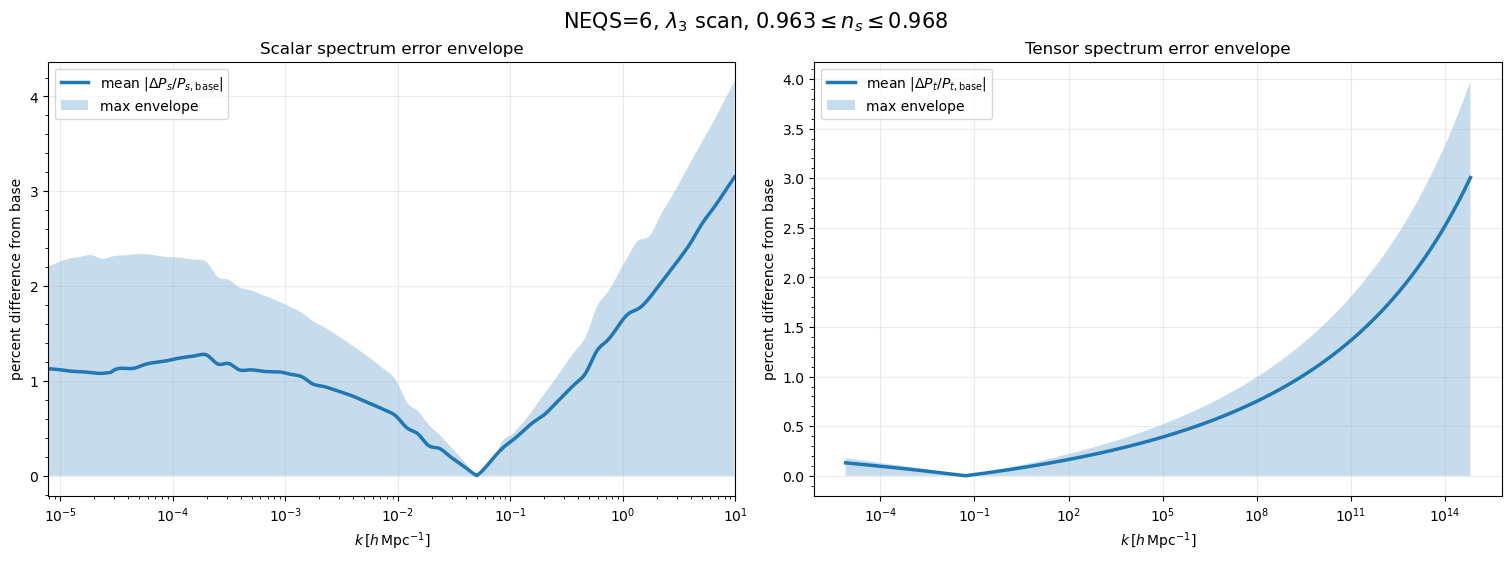

In [60]:
tilt_env_df = plot_filtered_Ps_Pt_error_envelopes_with_tilts(
    NEQS=6,
    lamX_values=lam3_values,
    baseX=-4.6097100000e-6,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    ns_min=0.963,
    ns_max=0.968,
    k_ref=0.05,
    k_fit_min=0.05,
    k_fit_max=10.0,
    k_max_scalar=10.0,
    save_name="neqs6_lam3_filtered_Ps_Pt_error_envelopes.png"
)

## NEQs = 7 and $\lambda_4$:


Summary for NEQS=7, parameter=lam4
Total models found: 120
Parameter range: -4.800e-03 to 4.900e-03

Missing files for lam4 = -4.80000e-03
Missing files for lam4 = -4.70000e-03
Missing files for lam4 = -4.60000e-03
Missing files for lam4 = -4.40000e-03
Missing files for lam4 = -4.30000e-03
Missing files for lam4 = -4.20000e-03
Missing files for lam4 = -4.00000e-03
Missing files for lam4 = -3.80000e-03
Missing files for lam4 = -3.70000e-03
Missing files for lam4 = -3.60000e-03
Missing files for lam4 = -3.30000e-03
Missing files for lam4 = -3.20000e-03
Missing files for lam4 = -3.00000e-03
Missing files for lam4 = -2.70000e-03
Missing files for lam4 = -2.60000e-03
Missing files for lam4 = -2.50000e-03
Missing files for lam4 = -2.20000e-03
Missing files for lam4 = -2.00000e-03
Missing files for lam4 = -1.90000e-03
Missing files for lam4 = -1.50000e-03
Missing files for lam4 = -1.20000e-03
Missing files for lam4 = -1.10000e-03
Missing files for lam4 = -1.00000e-03
Missing files for lam4 =

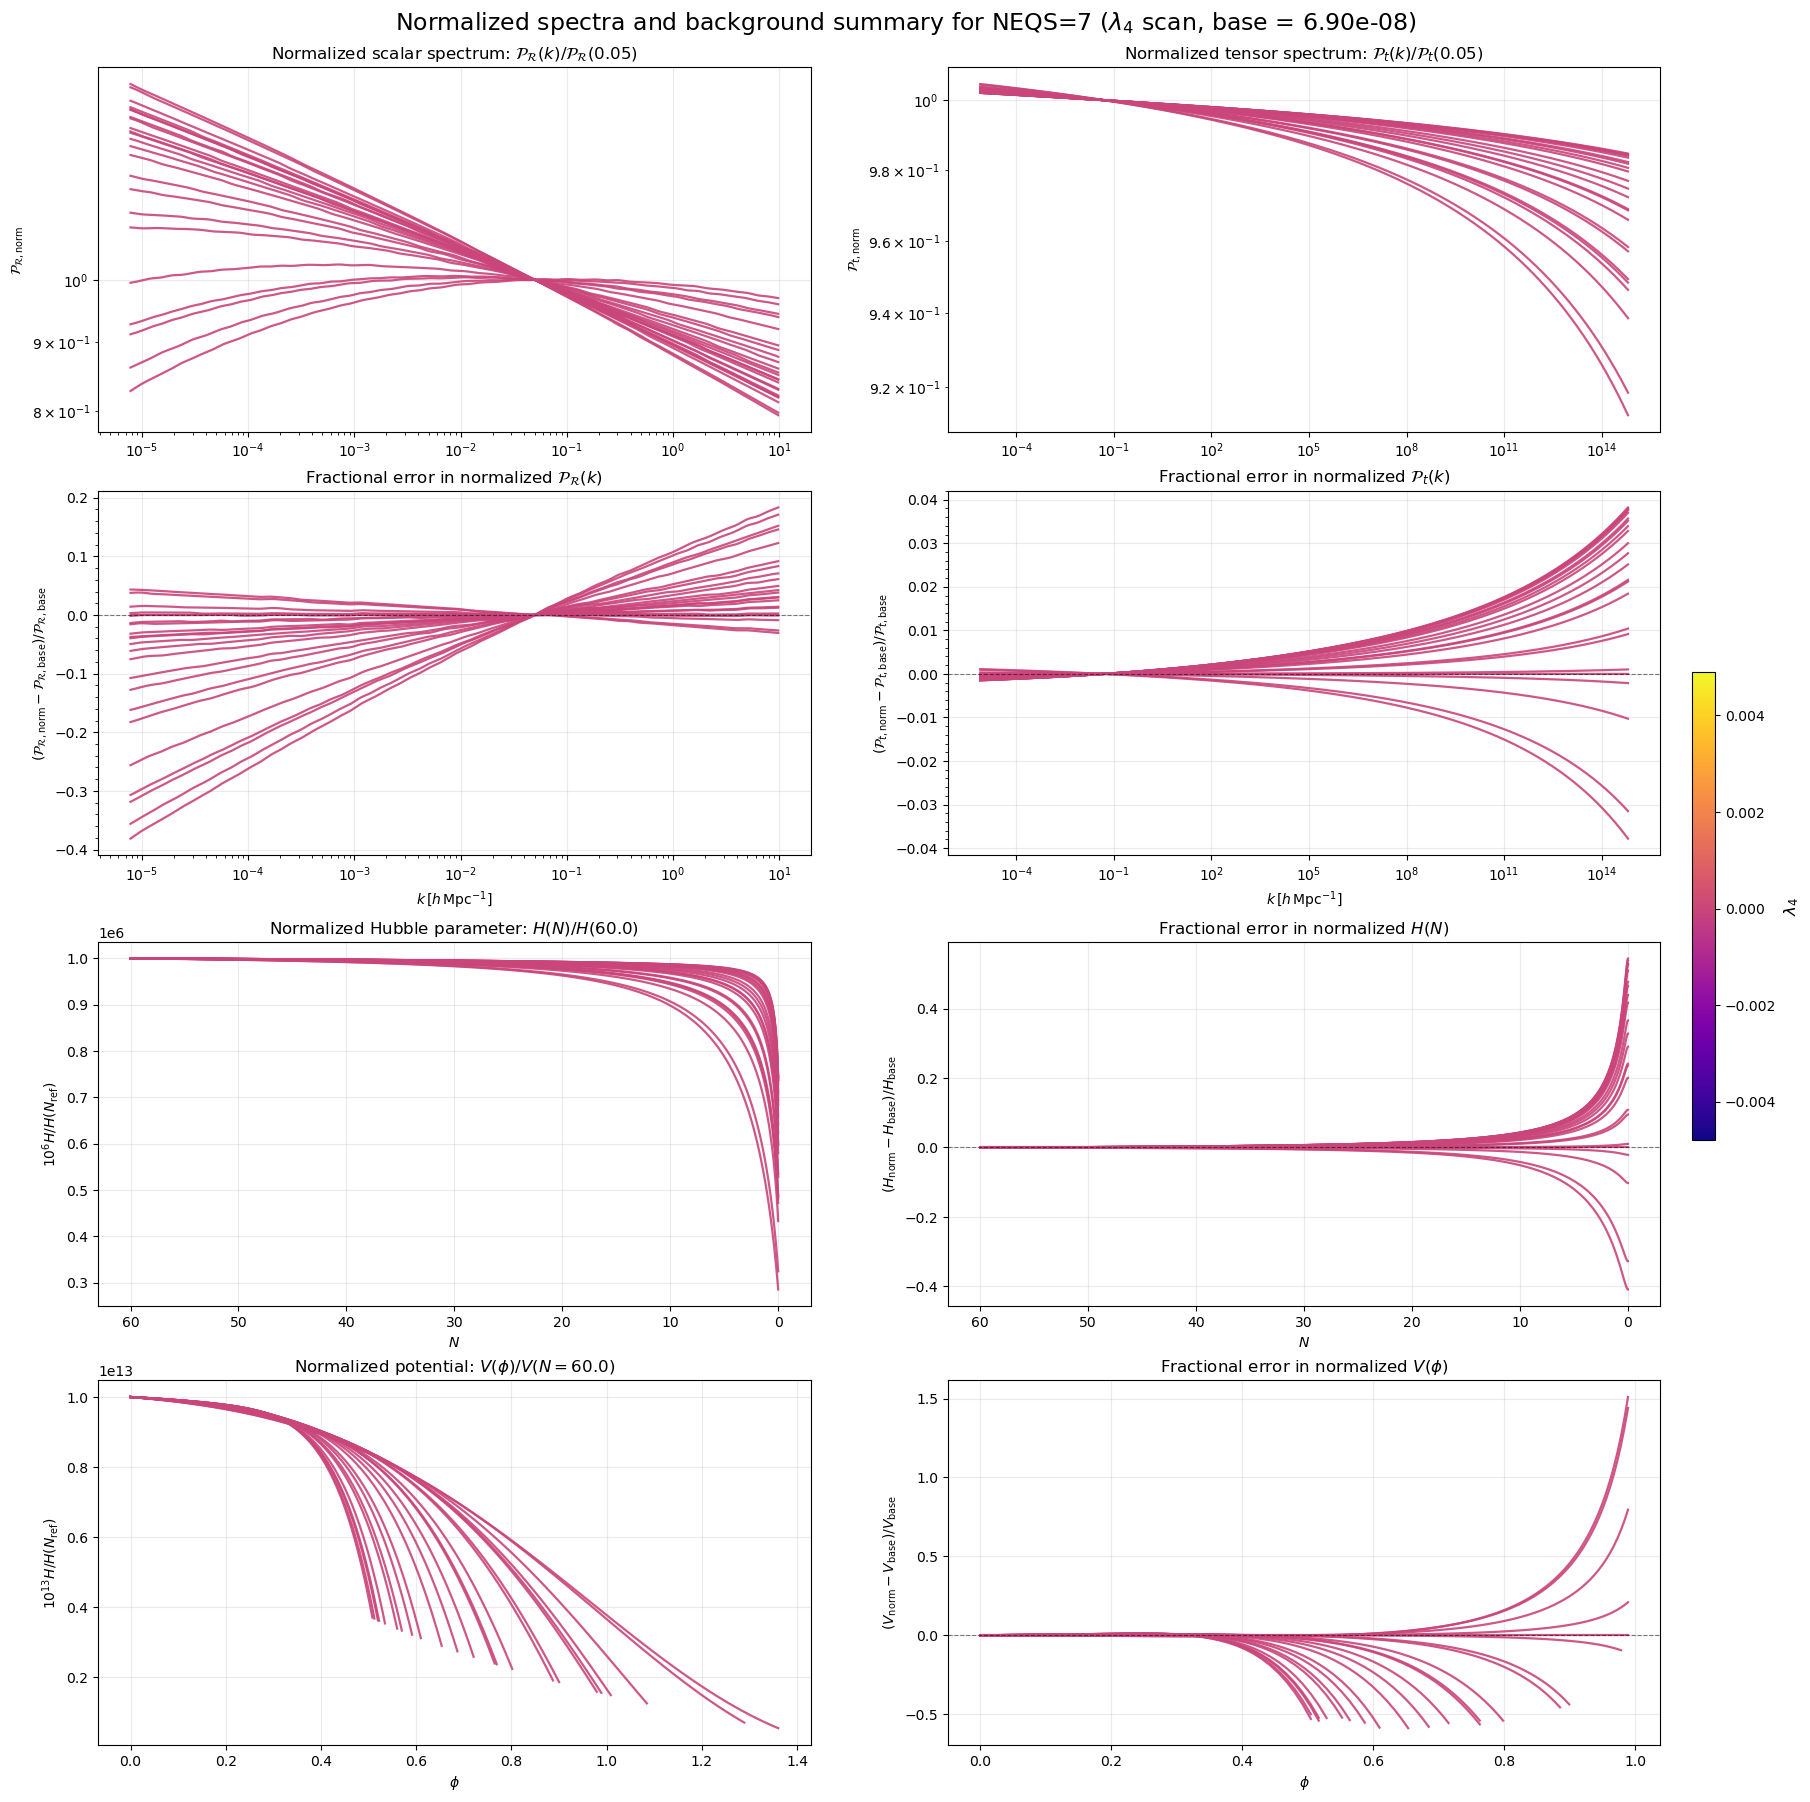

phi at max N: 0.0
phi at min N: 0.9887568
            lamX  mean_dPt_pct  max_dPt_pct  mean_dPs_pct  max_dPs_pct  \
0  -6.000000e-08     -0.756442     3.781481      0.889409     4.349833   
1  -5.400000e-08     -0.636452     3.149394      0.790533     3.839148   
2   0.000000e+00     -0.214986     1.028664      0.366481     1.543432   
3   5.000000e-08     -0.044637     0.210752      0.135759     0.442205   
4   6.900000e-08      0.000000     0.000000      0.000000     0.000000   
5   7.900000e-08      0.021888     0.102858      0.084064     0.261471   
6   2.000000e-07      0.197336     0.914618     -0.135121     1.359827   
7   2.200000e-07      0.225101     1.041057     -0.226968     1.581635   
8   5.000000e-07      0.403855     1.841441     -0.514332     3.186121   
9   6.700000e-07      0.467936     2.122363     -0.634560     3.739229   
10  7.000000e-07      0.476424     2.159307     -0.660088     3.965506   
11  1.000000e-06      0.558759     2.514694     -0.826931     4.954678

In [44]:

base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"
lam4_values = get_param_values_from_dirs(7, "lam4", base_path_root)


stats_df = plot_big_normalized_scan_summary(
    NEQS=7,
    lamX_values=lam4_values,
    baseX=6.9e-08,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    index=0,
    k_ref=0.05,
    N_ref=60.0,
    H_scale=1e6,    
    V_scale=1e13,    
    save_name="expanded_neqs7_lam4_big_summary.png"
)

print(stats_df)

## NEQs = 8 and $\lambda_5$:


Summary for NEQS=8, parameter=lam5
Total models found: 97
Parameter range: -4.800e-04 to 4.700e-04

Missing files for lam5 = -4.80000e-04
Missing files for lam5 = -3.90000e-04
Missing files for lam5 = -3.80000e-04
Skipping lam5 = -3.50000e-04: Reference V(N_ref) too small at N_ref=60.0: 7.912e-23
Skipping lam5 = -3.30000e-04: Reference V(N_ref) too small at N_ref=60.0: 1.547e-22
Skipping lam5 = -2.20000e-04: Reference V(N_ref) too small at N_ref=60.0: 2.973e-21
Missing files for lam5 = 3.80000e-09
Missing files for lam5 = 5.20000e-09
Missing files for lam5 = 5.40000e-09
Missing files for lam5 = 7.40000e-09
Missing files for lam5 = 7.70000e-09
Missing files for lam5 = 1.10000e-08
Missing files for lam5 = 1.70000e-08
Missing files for lam5 = 2.10000e-08
Missing files for lam5 = 2.30000e-08
Missing files for lam5 = 2.30000e-07
Missing files for lam5 = 2.60000e-07
Missing files for lam5 = 3.50000e-07
Missing files for lam5 = 3.80000e-07
Missing files for lam5 = 5.00000e-07
Missing files f

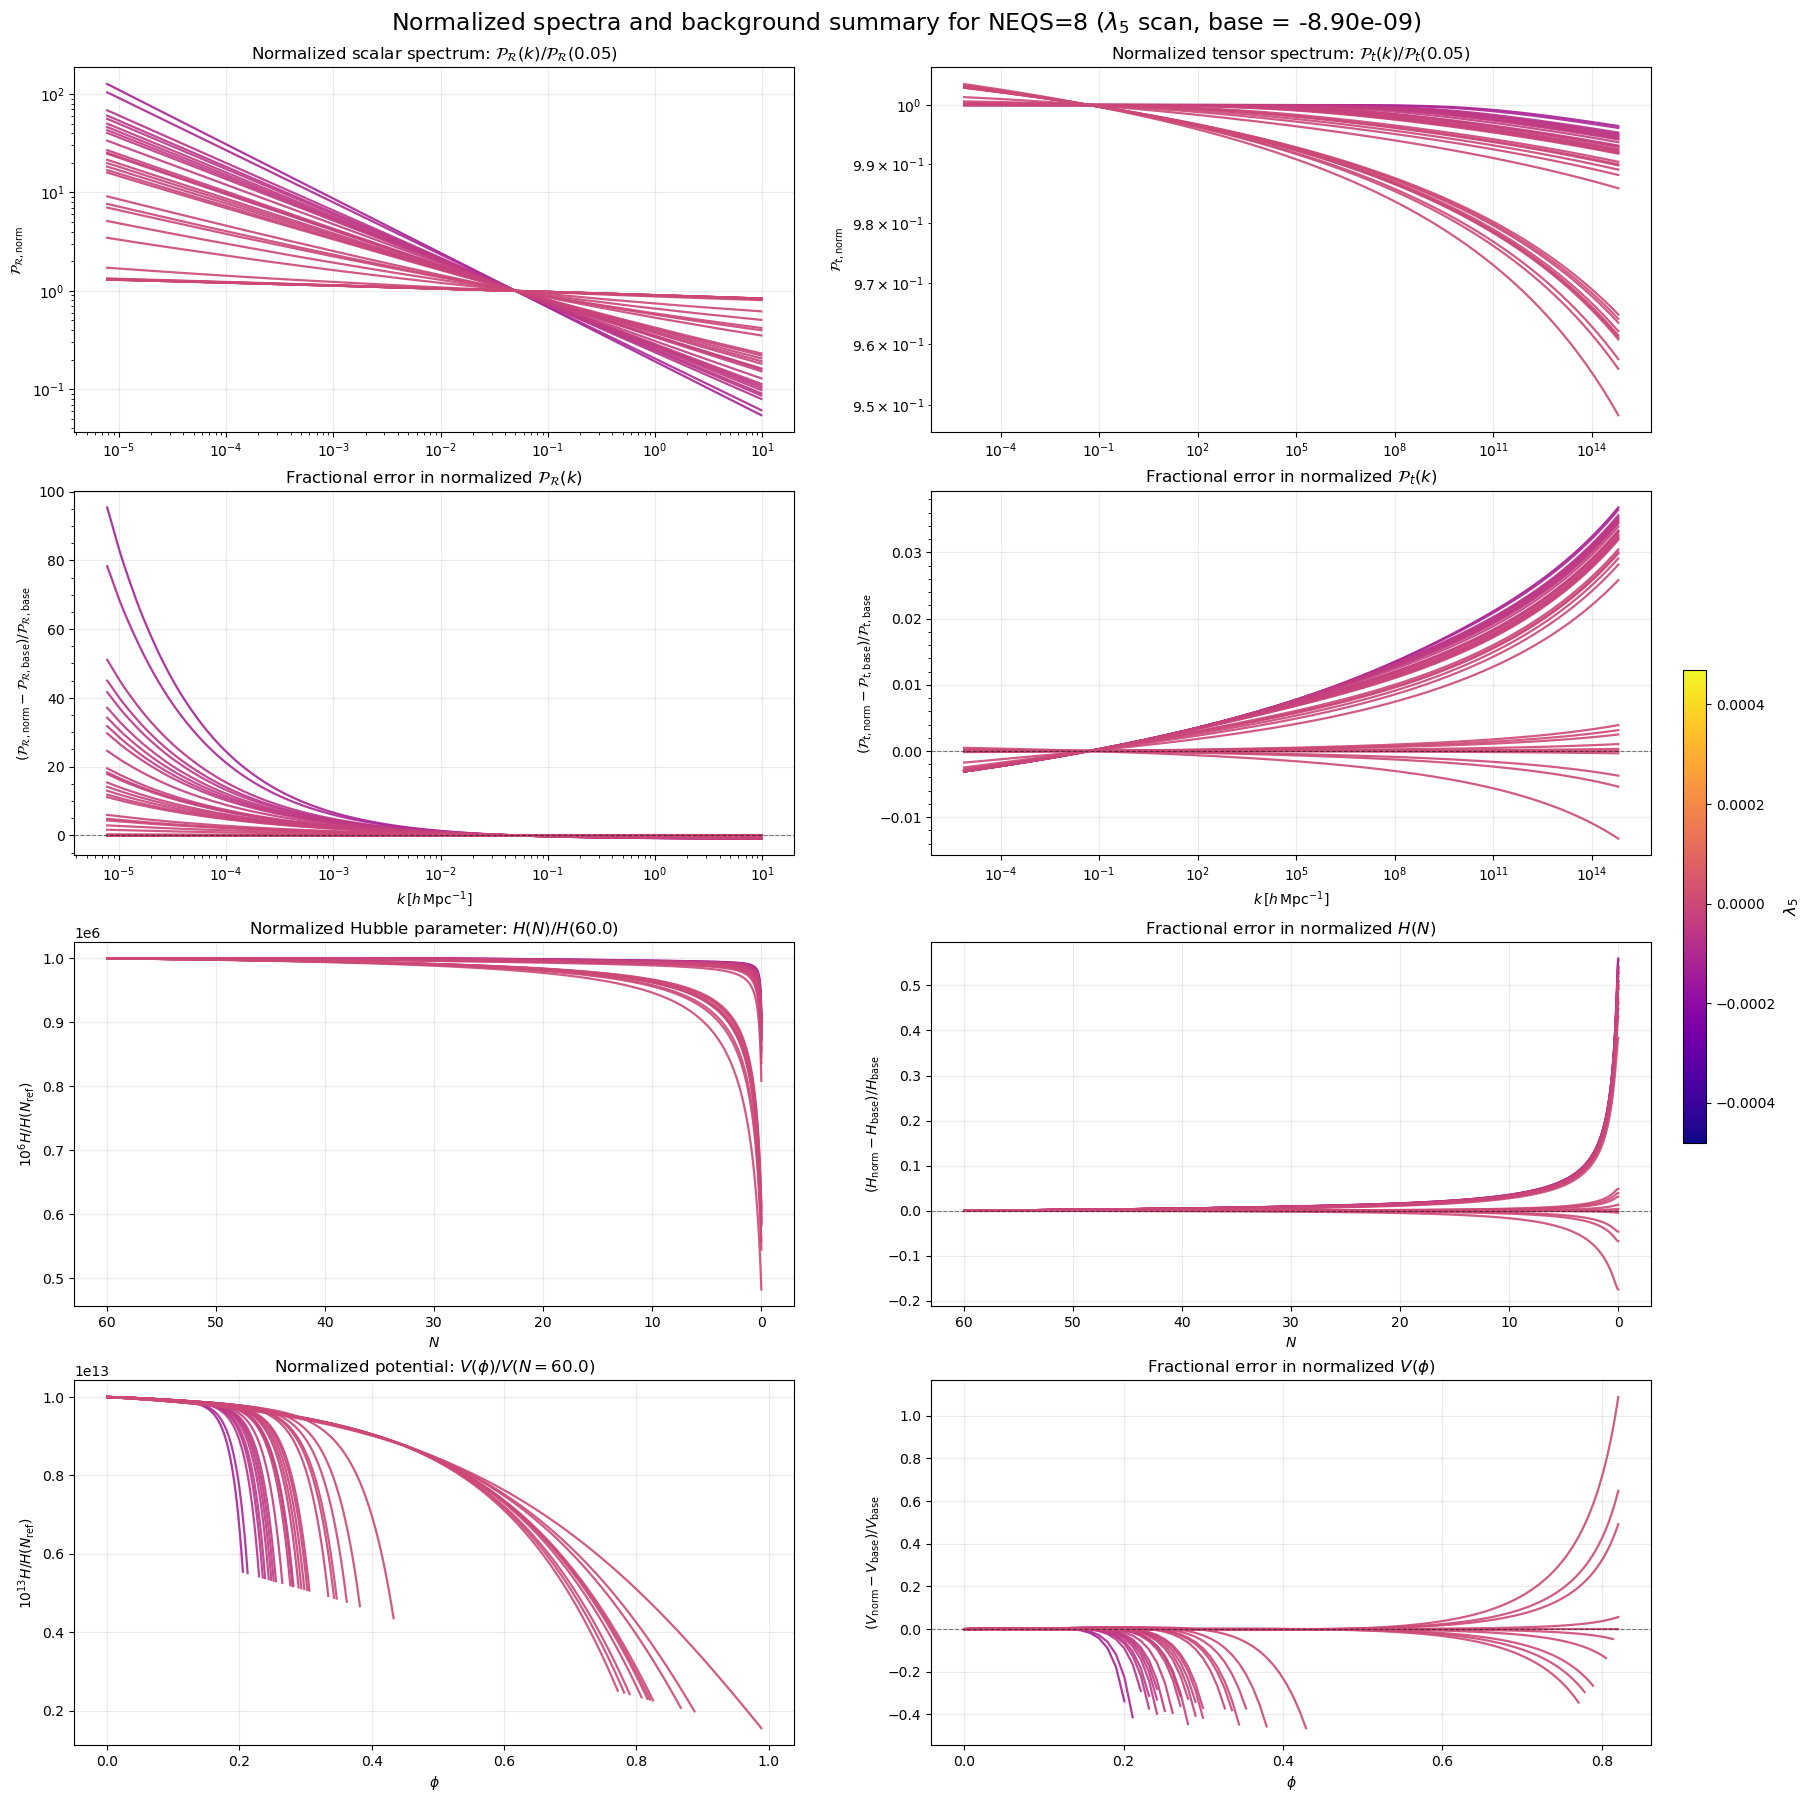

phi at max N: 0.0
phi at min N: 0.820774
            lamX  mean_dPt_pct  max_dPt_pct  mean_dPs_pct  max_dPs_pct  \
0  -1.300000e-04      1.031615     3.678144   1220.398388  9537.704838   
1  -1.100000e-04      1.023531     3.644015   1034.256945  7828.541578   
2  -7.300000e-05      1.001457     3.561322    722.190143  5108.194234   
3  -6.500000e-05      0.993507     3.534313    649.170919  4500.943027   
4  -6.000000e-05      0.988309     3.517270    607.980253  4165.304318   
5  -5.300000e-05      0.980023     3.490994    551.827834  3712.089647   
6  -4.900000e-05      0.973902     3.472214    515.218474  3423.431369   
7  -4.600000e-05      0.968116     3.454901    483.544026  3178.457907   
8  -4.200000e-05      0.962488     3.438438    456.339805  2967.193224   
9  -3.500000e-05      0.945881     3.391761    388.472545  2458.454390   
10 -2.800000e-05      0.923549     3.332659    318.313179  1950.851432   
11 -2.600000e-05      0.917159     3.316384    301.650240  1834.563773 

In [45]:

base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"
lam5_values = get_param_values_from_dirs(8, "lam5", base_path_root)


stats_df = plot_big_normalized_scan_summary(
    NEQS=8,
    lamX_values=lam5_values,
    baseX=-8.9e-09,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    index=0,
    k_ref=0.05,
    N_ref=60.0,
    H_scale=1e6,    
    V_scale=1e13,    
    save_name="expanded_neqs8_lam5_big_summary.png"
)

print(stats_df)